#HR NET

In [1]:
!pip install torch torchvision albumentations opencv-python numpy
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [2]:
import shutil
import os
src_path = r"/content/drive/MyDrive/BFL/Annotations/"
destination_path =r"/content/dataset"
if os.path.exists(src_path):
  shutil.copytree(src_path, destination_path)
  print("done copying")
else:
  print("file not found")

done copying


In [3]:
import os, cv2, numpy as np

IMG_DIR        = "/content/dataset/images"
LABEL_DIR      = "/content/dataset/labels"
BLADE_MASK_DIR = "/content/dataset/blade_masks"
MASKED_IMG_DIR = "/content/dataset/images"

os.makedirs(BLADE_MASK_DIR, exist_ok=True)
os.makedirs(MASKED_IMG_DIR, exist_ok=True)

BLADE_CLASS = 0   # blade outline class

def connect_mask(mask):
    """
    Connect gaps and smooth blade mask
    """
    kernel = np.ones((7, 7), np.uint8)

    # Close gaps
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Optional: expand slightly (helps keep edge defects)
    mask = cv2.dilate(mask, kernel, iterations=1)

    return mask

def generate_blade_masks():
    total, no_blade = 0, 0

    for img_name in os.listdir(IMG_DIR):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        base       = os.path.splitext(img_name)[0]
        img_path   = os.path.join(IMG_DIR,   img_name)
        label_path = os.path.join(LABEL_DIR, base + ".txt")
        mask_path  = os.path.join(BLADE_MASK_DIR, base + ".png")
        out_path   = os.path.join(MASKED_IMG_DIR,  img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]
        blade_mask = np.zeros((h, w), dtype=np.uint8)
        found_blade = False

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls = int(parts[0])
                if cls != BLADE_CLASS:
                    continue

                coords = list(map(float, parts[1:]))
                pts = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    pts.append([x, y])

                if len(pts) < 3:
                    continue

                pts = np.array(pts, np.int32)
                cv2.fillPoly(blade_mask, [pts], 255)
                found_blade = True

        if not found_blade:
            blade_mask[:] = 255
            no_blade += 1
            print(f"⚠️ No blade label: {img_name} — using full image")

        # 🔥 CONNECT THE MASK HERE
        blade_mask = connect_mask(blade_mask)

        # Apply mask
        masked_img = img.copy()
        masked_img[blade_mask == 0] = 0

        # Save results
        cv2.imwrite(mask_path, blade_mask)
        cv2.imwrite(out_path, masked_img)

        total += 1

    print(f"\n✅ Done! Total: {total} | No blade label: {no_blade}")

generate_blade_masks()

⚠️ No blade label: 5a4cfe80-616.jpg — using full image
⚠️ No blade label: 92f7ced8-BLADE_05_Top_trailing_edge.jpg — using full image
⚠️ No blade label: 1614f1b1-48.jpg — using full image
⚠️ No blade label: 53913bcd-BLADE-3_Sensitive_Zone_Opp_leading_side_f4.jpg — using full image
⚠️ No blade label: 063aee08-BLADE-3_Middle_trailing_part.jpg — using full image
⚠️ No blade label: 819f50e0-98.jpg — using full image
⚠️ No blade label: cdf1c860-BLADE_04_Critical_point_leading_side.jpg — using full image
⚠️ No blade label: 69827cb1-BLADE-4_Middle_trailing_edge.jpg — using full image
⚠️ No blade label: b70450f3-89.jpg — using full image
⚠️ No blade label: 7b842dbc-79.jpg — using full image
⚠️ No blade label: 6155b4f9-BLADE-2_Critical_point_leading_side_FOCUS_14.jpg — using full image
⚠️ No blade label: 09070985-BLADE-2_Weld_face_Trailing_Edge_FOCUS_04.jpg — using full image
⚠️ No blade label: ca6252fc-BLADE_04_Weld_face_Trailing_Edge.jpg — using full image
⚠️ No blade label: 422daef3-BLADE-3_M

In [4]:
import os

base_path = destination_path

label_dirs = [
    os.path.join(base_path, "labels"),
    # os.path.join(base_path, "labels/val")
]

image_dirs = [
    os.path.join(base_path, "images"),
    # os.path.join(base_path, "images/val")
]

ignore_classes = [0]   # remove Blade
total_classes = 9

# Create mapping
new_class_id = {}
new_id = 0
for old_id in range(total_classes):
    if old_id not in ignore_classes:
        new_class_id[old_id] = new_id
        new_id += 1

print("Mapping:", new_class_id)

for labels_folder, images_folder in zip(label_dirs, image_dirs):

    for file in os.listdir(labels_folder):
        if not file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_folder, file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            try:
                cls = int(parts[0])
            except:
                continue

            if cls in ignore_classes:
                continue

            if cls not in new_class_id:
                continue

            parts[0] = str(new_class_id[cls])
            new_lines.append(" ".join(parts) + "\n")

        if len(new_lines) == 0:
            os.remove(label_path)
            img_name = file.replace(".txt", ".jpg")
            img_path = os.path.join(images_folder, img_name)

            if os.path.exists(img_path):
                os.remove(img_path)

        else:
            with open(label_path, "w") as f:
                f.writelines(new_lines)

Mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


In [5]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class YOLOSegDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=512):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def polygon_to_mask(self, poly, h, w):
        mask = np.zeros((h, w), dtype=np.uint8)
        poly = np.array(poly).reshape(-1, 2)
        poly[:, 0] *= w
        poly[:, 1] *= h
        poly = poly.astype(np.int32)
        cv2.fillPoly(mask, [poly], 1)
        return mask

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        img = cv2.resize(img, (self.img_size, self.img_size))
        h, w = img.shape[:2]

        mask = np.zeros((self.img_size, self.img_size, NUM_CLASSES), dtype=np.uint8)

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    data = list(map(float, line.strip().split()))
                    cls = int(data[0])
                    poly = data[1:]
                    m = self.polygon_to_mask(poly, self.img_size, self.img_size)
                    mask[:, :, cls] = np.maximum(mask[:, :, cls], m)

        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(mask).permute(2, 0, 1).float()

        return img, mask

In [7]:
import segmentation_models_pytorch as smp
NUM_CLASSES = 8
model = smp.FPN(
    encoder_name="timm-regnety_032",   # strong for small datasets
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)

model.safetensors:   0%|          | 0.00/78.1M [00:00<?, ?B/s]

In [13]:
import torch
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2. * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)

    return 1 - dice.mean()
def focal_loss(pred, target, alpha=0.8, gamma=2):
    pred = torch.sigmoid(pred)

    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-bce)

    focal = alpha * (1 - pt) ** gamma * bce
    return focal.mean()
def loss_fn(pred, target):
    return 0.4 * focal_loss(pred, target) + 0.6 * dice_loss(pred, target)

In [11]:
import os
import shutil
import random

# Paths
IMG_DIR = "dataset/images"
LBL_DIR = "dataset/labels"

TRAIN_IMG = "dataset/images/train"
VAL_IMG   = "dataset/images/val"
TRAIN_LBL = "dataset/labels/train"
VAL_LBL   = "dataset/labels/val"

# Create folders
for d in [TRAIN_IMG, VAL_IMG, TRAIN_LBL, VAL_LBL]:
    os.makedirs(d, exist_ok=True)

# Get all images
images = [f for f in os.listdir(IMG_DIR)
          if f.lower().endswith((".jpg", ".jpeg", ".png"))]

random.seed(42)
random.shuffle(images)

# Split ratio
val_ratio = 0.2
split_idx = int(len(images) * (1 - val_ratio))

train_imgs = images[:split_idx]
val_imgs   = images[split_idx:]

def move_files(img_list, img_dst, lbl_dst):
    for img_name in img_list:
        src_img = os.path.join(IMG_DIR, img_name)
        dst_img = os.path.join(img_dst, img_name)

        lbl_name = os.path.splitext(img_name)[0] + ".txt"
        src_lbl = os.path.join(LBL_DIR, lbl_name)
        dst_lbl = os.path.join(lbl_dst, lbl_name)

        # Move image
        shutil.move(src_img, dst_img)

        # Move label if exists
        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dst_lbl)

# Move files
move_files(train_imgs, TRAIN_IMG, TRAIN_LBL)
move_files(val_imgs, VAL_IMG, VAL_LBL)

print(f"✅ Train: {len(train_imgs)} images")
print(f"✅ Val: {len(val_imgs)} images")

✅ Train: 198 images
✅ Val: 50 images


In [14]:
from torch.utils.data import DataLoader

train_ds = YOLOSegDataset("dataset/images/train", "dataset/labels/train", img_size=512)
val_ds   = YOLOSegDataset("dataset/images/val", "dataset/labels/val", img_size=512)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

for epoch in range(50):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        out = model(imgs)

        loss = loss_fn(out, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch} Train Loss: {train_loss/len(train_loader):.4f}")

Epoch 0 Train Loss: 0.6000
Epoch 1 Train Loss: 0.5409
Epoch 2 Train Loss: 0.4850
Epoch 3 Train Loss: 0.4464
Epoch 4 Train Loss: 0.4070
Epoch 5 Train Loss: 0.3795
Epoch 6 Train Loss: 0.3537
Epoch 7 Train Loss: 0.3316
Epoch 8 Train Loss: 0.3130
Epoch 9 Train Loss: 0.3019
Epoch 10 Train Loss: 0.2866
Epoch 11 Train Loss: 0.2768
Epoch 12 Train Loss: 0.2670
Epoch 13 Train Loss: 0.2505
Epoch 14 Train Loss: 0.2332
Epoch 15 Train Loss: 0.2246
Epoch 16 Train Loss: 0.2156
Epoch 17 Train Loss: 0.2149
Epoch 18 Train Loss: 0.2098
Epoch 19 Train Loss: 0.2053
Epoch 20 Train Loss: 0.2004
Epoch 21 Train Loss: 0.1856
Epoch 22 Train Loss: 0.1766
Epoch 23 Train Loss: 0.1736
Epoch 24 Train Loss: 0.1731
Epoch 25 Train Loss: 0.1674
Epoch 26 Train Loss: 0.1602
Epoch 27 Train Loss: 0.1617
Epoch 28 Train Loss: 0.1545
Epoch 29 Train Loss: 0.1501
Epoch 30 Train Loss: 0.1417
Epoch 31 Train Loss: 0.1434
Epoch 32 Train Loss: 0.1510
Epoch 33 Train Loss: 0.1485
Epoch 34 Train Loss: 0.1496
Epoch 35 Train Loss: 0.1530
Ep

In [15]:
with torch.no_grad():
    pred = torch.sigmoid(out)
    pred = (pred > 0.15).float()   # IMPORTANT: low threshold

In [16]:
import numpy as np

# 8 classes example
COLORS = [
    (255, 0, 0),    # Cutter
    (0, 255, 0),    # Fingerprint
    (0, 0, 255),    # Ink
    (255, 255, 0),  # Jig
    (255, 0, 255),  # Machining
    (0, 255, 255),  # Overcut
    (128, 128, 0),  # Pocket
    (128, 0, 128)   # Scratches
]

In [17]:
import cv2

def mask_to_color(mask):
    # mask shape: [C, H, W]
    mask = mask.cpu().numpy()
    C, H, W = mask.shape

    color_mask = np.zeros((H, W, 3), dtype=np.uint8)

    for c in range(C):
        color_mask[mask[c] > 0.5] = COLORS[c]

    return color_mask

In [20]:
import matplotlib.pyplot as plt
import torch

def visualize(model, dataset, idx=0, threshold=0.15):
    model.eval()

    img, gt_mask = dataset[idx]

    with torch.no_grad():
        inp = img.unsqueeze(0).to(device)
        out = model(inp)

        pred = torch.sigmoid(out)[0]
        pred = (pred > threshold).float().cpu()

    # Convert image
    img_np = img.permute(1,2,0).cpu().numpy()

    # Convert masks
    gt_color = mask_to_color(gt_mask)
    pred_color = mask_to_color(pred)

    # Overlay
    overlay = (img_np * 255).astype(np.uint8)
    overlay = cv2.addWeighted(overlay, 0.7, pred_color, 0.3, 0)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth")
    plt.imshow(gt_color)
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Prediction")
    plt.imshow(pred_color)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

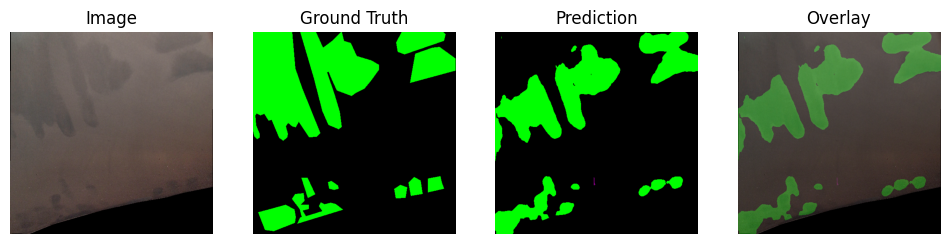

In [21]:
visualize(model, val_ds, idx=1)

In [23]:
torch.save(model.state_dict(), "/content/drive/MyDrive/hr_net.pth")

#unet

In [ ]:
TARGET_CLASSES = [0]

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# =========================
# PATHS
# =========================
IMG_DIR = "dataset/images/train"
LBL_DIR = "dataset/labels/train"

OUT_MASK_DIR = "scratch_masks/train"
os.makedirs(OUT_MASK_DIR, exist_ok=True)

# =========================
# TARGET CLASS
# =========================
TARGET_CLASSES = [7]  # scratches + black spots

# =========================
# FUNCTION
# =========================
def convert_to_binary_mask(img_path, label_path, save_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    if not os.path.exists(label_path):
        cv2.imwrite(save_path, mask)
        return

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = list(map(float, line.strip().split()))
        cls_id = int(parts[0])

        # only keep target class
        if cls_id not in TARGET_CLASSES:
            continue

        coords = parts[1:]

        points = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)

            # clip (VERY IMPORTANT)
            x = np.clip(x, 0, w-1)
            y = np.clip(y, 0, h-1)

            points.append([x, y])

        points = np.array(points, dtype=np.int32)

        # fill defect area as 1
        cv2.fillPoly(mask, [points], color=1)

    cv2.imwrite(save_path, mask * 255)  # multiply for visibility


# =========================
# RUN
# =========================
for img_name in tqdm(os.listdir(IMG_DIR)):
    if not img_name.endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(IMG_DIR, img_name)

    label_path = os.path.join(
        LBL_DIR,
        img_name.replace(".jpg", ".txt").replace(".png", ".txt")
    )

    save_path = os.path.join(
        OUT_MASK_DIR,
        img_name.replace(".jpg", ".png")
    )

    convert_to_binary_mask(img_path, label_path, save_path)

print("✅ Scratch + Blackspot masks created!")

100%|██████████| 314/314 [00:27<00:00, 11.37it/s]

✅ Scratch + Blackspot masks created!


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))

        bn = self.bottleneck(self.pool(d4))

        u4 = self.up4(bn)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class BinaryDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.imgs = os.listdir(img_dir)
        self.img_dir = img_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.imgs)



    def __getitem__(self, idx):
        IMG_SIZE = 512
        name = self.imgs[idx]

        img = cv2.imread(os.path.join(self.img_dir, name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(
            os.path.join(self.mask_dir, name.replace(".jpg", ".png")),
            0
        )

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=0)

        return (
            torch.tensor(img, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32)
        )

In [ ]:
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

dataset = BinaryDataset(
    "dataset/images/train",
    "scratch_masks/train"
)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss/len(loader)}")

Epoch 0: Loss = 0.3121325466074521
Epoch 1: Loss = 0.11264738893207116
Epoch 2: Loss = 0.07424330164360095
Epoch 3: Loss = 0.06312303652963307
Epoch 4: Loss = 0.06053021340336226
Epoch 5: Loss = 0.05784829580991328
Epoch 6: Loss = 0.056845848248163355
Epoch 7: Loss = 0.05562409848163399
Epoch 8: Loss = 0.054578210521913785
Epoch 9: Loss = 0.05473523876995225
Epoch 10: Loss = 0.0555153464238289
Epoch 11: Loss = 0.05571744267982018
Epoch 12: Loss = 0.05510057452358777
Epoch 13: Loss = 0.0550209956267212
Epoch 14: Loss = 0.05456740949067134
Epoch 15: Loss = 0.05350645018529288
Epoch 16: Loss = 0.05407629626555533
Epoch 17: Loss = 0.05330259720735912
Epoch 18: Loss = 0.05386063645157633
Epoch 19: Loss = 0.052892791142663625
Epoch 20: Loss = 0.05510189383043141
Epoch 21: Loss = 0.05501359662253268
Epoch 22: Loss = 0.05330290513325341
Epoch 23: Loss = 0.05350940698121168
Epoch 24: Loss = 0.05410388738058413
Epoch 25: Loss = 0.053062901207351985
Epoch 26: Loss = 0.05314461368171475
Epoch 27: 

KeyboardInterrupt: 

In [ ]:
def predict(model, image):
    model.eval()

    IMG_SIZE = 512  # MUST match training

    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))  # ✅ FIX
    img = img / 255.0
    img = np.transpose(img, (2,0,1))

    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)
        pred = torch.sigmoid(pred)

    mask = pred.squeeze().cpu().numpy()
    mask = (mask > 0.1).astype(np.uint8)

    # resize back to original
    mask = cv2.resize(mask, (image.shape[1], image.shape[0]))

    return mask

In [ ]:
def overlay(image, mask):
    overlay = image.copy()
    overlay[mask == 1] = (0,0,255)

    return cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

In [ ]:
import cv2
import os

image_filename = "/content/dataset/images/val/325d766e-Top_mid_part.jpg" # Using an image known to exist from your validation set
image_path = os.path.join("/content/dataset/images/val", image_filename)

img = cv2.imread(image_path)

if img is None:
    print(f"Error: Image not found or could not be loaded at {image_path}")
else:
    mask_pred = predict(model, img)
    result = overlay(img, mask_pred)
    cv2.imwrite("result.png", result)
    print(f"Result saved to result.png for image {image_filename}")

Result saved to result.png for image /content/dataset/images/val/325d766e-Top_mid_part.jpg


In [ ]:
torch.save(model.state_dict(), "unet.pth")

#Unet Part2

In [ ]:
!pip install albumentations opencv-python

In [ ]:
import shutil
import os
src_path = r"/content/drive/MyDrive/BFL/Annotations/"
destination_path =r"/content/dataset"
if os.path.exists(src_path):
  shutil.copytree(src_path, destination_path)
  print("done copying")
else:
  print("file not found")

done copying


In [ ]:
import os

base_path = destination_path

label_dirs = [
    os.path.join(base_path, "labels"),
    # os.path.join(base_path, "labels/val")
]

image_dirs = [
    os.path.join(base_path, "images"),
    # os.path.join(base_path, "images/val")
]

ignore_classes = [0]   # remove Blade
total_classes = 9

# Create mapping
new_class_id = {}
new_id = 0
for old_id in range(total_classes):
    if old_id not in ignore_classes:
        new_class_id[old_id] = new_id
        new_id += 1

print("Mapping:", new_class_id)

for labels_folder, images_folder in zip(label_dirs, image_dirs):

    for file in os.listdir(labels_folder):
        if not file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_folder, file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            try:
                cls = int(parts[0])
            except:
                continue

            if cls in ignore_classes:
                continue

            if cls not in new_class_id:
                continue

            parts[0] = str(new_class_id[cls])
            new_lines.append(" ".join(parts) + "\n")

        if len(new_lines) == 0:
            os.remove(label_path)
            img_name = file.replace(".txt", ".jpg")
            img_path = os.path.join(images_folder, img_name)

            if os.path.exists(img_path):
                os.remove(img_path)

        else:
            with open(label_path, "w") as f:
                f.writelines(new_lines)

Mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


In [ ]:
import os, cv2, numpy as np

IMG_DIR = "/content/dataset/images"
LABEL_DIR = "/content/dataset/labels"
MASK_DIR = "/content/dataset/masks_multi"

NUM_CLASSES = 8

os.makedirs(MASK_DIR, exist_ok=True)

def convert_yolo_to_multilabel():
    for img_name in os.listdir(IMG_DIR):
        img_path = os.path.join(IMG_DIR, img_name)
        label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        # MULTI-CHANNEL MASK
        mask = np.zeros((h, w, NUM_CLASSES), dtype=np.uint8)

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = list(map(float, line.strip().split()))
                cls = int(parts[0])
                coords = parts[1:]

                pts = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    pts.append([x, y])

                pts = np.array(pts, np.int32)

                # Fill ONLY that class channel
                channel = mask[:, :, cls].copy()
                cv2.fillPoly(channel, [pts], 1)
                mask[:, :, cls] = channel

        # Save as numpy
        np.save(os.path.join(MASK_DIR, img_name.replace(".jpg", ".npy")), mask)

    print("✅ Multi-label masks created!")

convert_yolo_to_multilabel()

⚠️ Skipping train — folder not found
⚠️ Skipping val — folder not found
✅ Done! Processed: 0, Skipped: 0


In [ ]:
import os, numpy as np

MASK_DIR = "/content/dataset/masks_multi"
NUM_CLASSES = 8
CLASS_NAMES = ["Cutter","Fingerprint","Ink","Jig","Machining","Overcut","Pocket","Scratches"]

counts = np.zeros(NUM_CLASSES)
for f in os.listdir(MASK_DIR):
    if f.endswith(".npy"):
        mask = np.load(os.path.join(MASK_DIR, f))
        counts += mask.sum(axis=(0,1))

print("Class distribution across ALL masks:\n")
total = counts.sum()
for i, (name, c) in enumerate(zip(CLASS_NAMES, counts)):
    bar = "█" * int(40 * c / total) if total > 0 else ""
    print(f"  [{i}] {name:<20} {int(c):>10,} px  {100*c/total:.2f}%  {bar}")

# Compute pos_weight for BCEWithLogitsLoss
print("\n✅ Suggested pos_weight for training:")
total_px = 2160 * 3840 * len(os.listdir(MASK_DIR))
for i, (name, c) in enumerate(zip(CLASS_NAMES, counts)):
    neg = total_px - c
    pw = neg / (c + 1e-8)
    pw = min(pw, 50)  # cap at 50
    print(f"  class {i} ({name}): pos_weight = {pw:.1f}")

Class distribution across ALL masks:

  [0] Cutter               18,089,502 px  14.15%  █████
  [1] Fingerprint          16,486,030 px  12.90%  █████
  [2] Ink                   2,929,236 px  2.29%  
  [3] Jig                     118,726 px  0.09%  
  [4] Machining            68,598,126 px  53.66%  █████████████████████
  [5] Overcut               1,032,992 px  0.81%  
  [6] Pocket                8,258,739 px  6.46%  ██
  [7] Scratches            12,324,742 px  9.64%  ███

✅ Suggested pos_weight for training:
  class 0 (Cutter): pos_weight = 48.1
  class 1 (Fingerprint): pos_weight = 50.0
  class 2 (Ink): pos_weight = 50.0
  class 3 (Jig): pos_weight = 50.0
  class 4 (Machining): pos_weight = 11.9
  class 5 (Overcut): pos_weight = 50.0
  class 6 (Pocket): pos_weight = 50.0
  class 7 (Scratches): pos_weight = 50.0


In [ ]:
import random
import numpy as np

def crop_with_defect(image, mask, size=512):
    h, w = image.shape[:2]

    # Combine all classes → find defect pixels
    combined = mask.sum(axis=2)

    ys, xs = np.where(combined > 0)

    # If no defect → random crop
    if len(xs) == 0:
        x = random.randint(0, max(0, w - size))
        y = random.randint(0, max(0, h - size))
    else:
        # Pick random defect pixel
        idx = random.randint(0, len(xs)-1)
        cx, cy = xs[idx], ys[idx]

        # Center crop around defect
        x = max(0, cx - size // 2)
        y = max(0, cy - size // 2)

        x = min(x, w - size)
        y = min(y, h - size)

    crop_img = image[y:y+size, x:x+size]
    crop_mask = mask[y:y+size, x:x+size]

    return crop_img, crop_mask

In [ ]:
import albumentations as A

train_transform = A.Compose([
    # A.RandomCrop(512, 512,p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.Rotate(limit=10, p=0.5),
    A.CLAHE(p=0.3),
])

val_transform = A.Compose([
    A.Resize(512, 512)
])

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
class BladeDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs = os.listdir(img_dir)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.imgs)   # ✅ FIX

    def __getitem__(self, idx):
      name = self.imgs[idx]

      img = cv2.imread(os.path.join(self.img_dir, name))
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      mask = np.load(
          os.path.join(self.mask_dir, name.replace(".jpg", ".npy"))
      )  # (H, W, 8)

      # 🔥 crop first
      img, mask = crop_with_defect(img, mask, size=512)

      # 🔥 augmentation (IMPORTANT)
      if self.transform:
          aug = self.transform(image=img, mask=mask)
          img = aug["image"]
          mask = aug["mask"]

      # 🔥 normalize image
      img = img / 255.0
      img = np.transpose(img, (2, 0, 1))  # (3, H, W)

      # 🚨 CRITICAL FIX
      mask = np.transpose(mask, (2, 0, 1))  # (8, H, W)

      return (
          torch.tensor(img, dtype=torch.float32),
          torch.tensor(mask, dtype=torch.float32)
      )

In [ ]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.d1 = DoubleConv(3,64)
        self.d2 = DoubleConv(64,128)
        self.d3 = DoubleConv(128,256)
        self.pool = nn.MaxPool2d(2)

        self.b = DoubleConv(256,512)

        self.u1 = nn.ConvTranspose2d(512,256,2,2)
        self.c1 = DoubleConv(512,256)

        self.u2 = nn.ConvTranspose2d(256,128,2,2)
        self.c2 = DoubleConv(256,128)

        self.u3 = nn.ConvTranspose2d(128,64,2,2)
        self.c3 = DoubleConv(128,64)

        self.out = nn.Conv2d(64,n_classes,1)

    def forward(self,x):
        x1 = self.d1(x)
        x2 = self.d2(self.pool(x1))
        x3 = self.d3(self.pool(x2))

        b = self.b(self.pool(x3))

        u1 = self.c1(torch.cat([self.u1(b), x3],1))
        u2 = self.c2(torch.cat([self.u2(u1), x2],1))
        u3 = self.c3(torch.cat([self.u3(u2), x1],1))

        return self.out(u3)

In [ ]:
def dice_loss(pred, target):
    pred = torch.softmax(pred, dim=1)
    target_oh = torch.nn.functional.one_hot(target, num_classes=9).permute(0,3,1,2).float()

    inter = (pred * target_oh).sum((2,3))
    union = pred.sum((2,3)) + target_oh.sum((2,3))

    return 1 - (2*inter/(union+1e-8)).mean()

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        pt = probs * targets + (1 - probs) * (1 - targets)
        focal = (1 - pt) ** self.gamma * bce

        if self.alpha is not None:
            focal = self.alpha.view(1, -1, 1, 1) * focal

        return focal.mean()

In [ ]:
# class FocalLoss(nn.Module):
#     def __init__(self, gamma=2, weight=None):
#         super().__init__()
#         self.gamma = gamma
#         self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none')

#     def forward(self, pred, target):
#         ce_loss = self.ce(pred, target)  # (B,H,W)
#         pt = torch.exp(-ce_loss)
#         focal_loss = ((1 - pt) ** self.gamma) * ce_loss
#         return focal_loss.mean()
# focal = FocalLoss(gamma=2, weight=weights)

# def total_loss(pred, target):
#     return focal(pred, target) + dice_loss(pred, target)

In [ ]:
def compute_iou(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()

    ious = []

    for c in range(pred.shape[1]):
        p = pred[:, c]
        t = target[:, c]

        intersection = (p * t).sum()
        union = (p + t).clamp(0,1).sum()

        if union == 0:
            iou = torch.tensor(1.0)
        else:
            iou = intersection / union

        ious.append(iou.item())

    return ious

In [ ]:
def compute_class_weights(dataset, num_classes=3):
    total_pixels = 0
    class_pixels = torch.zeros(num_classes)

    for i in range(len(dataset)):
        _, mask = dataset[i]  # mask: (C,H,W)
        class_pixels += mask.sum(dim=(1,2))
        total_pixels += mask.shape[1] * mask.shape[2]

    # avoid division by zero
    class_pixels = torch.clamp(class_pixels, min=1)

    weights = total_pixels / class_pixels
    weights = weights / weights.mean()  # normalize

    return weights

In [ ]:
dataset = BladeDataset(IMG_DIR, MASK_DIR, transform=train_transform)

class_weights = compute_class_weights(dataset, NUM_CLASSES)
print("Class weights:", class_weights)

RuntimeError: The size of tensor a (9) must match the size of tensor b (8) at non-singleton dimension 0

In [ ]:
os.makedirs("/content/model_weights", exist_ok=True)

In [ ]:
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn

# -----------------------
# MULTI-LABEL DICE LOSS
# -----------------------
def dice_loss_multilabel(pred, target, smooth=1e-8):
    pred = torch.sigmoid(pred)

    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

# -----------------------
# TRAIN FUNCTION
# -----------------------
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = BladeDataset(IMG_DIR, MASK_DIR, transform=train_transform)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=4, pin_memory=True)

    model = UNet(n_classes=8).to(device)

    # ✅ CORRECT LOSS
    # criterion = nn.BCEWithLogitsLoss()
    pos_weight = torch.tensor([12]*8, dtype=torch.float32).to(device)

    # criterion = nn.BCEWithLogitsLoss(
    #     pos_weight=pos_weight.view(1, 8, 1, 1)   # 🔥 FIX
    # )
    criterion = FocalLoss(alpha=class_weights.to(device), gamma=2)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    scaler = torch.cuda.amp.GradScaler()

    best_val = float("inf")
    patience = 20
    counter = 0

    for epoch in range(60):

        # ---------------- TRAIN ----------------
        model.train()
        train_loss = 0

        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(imgs)
                # loss = criterion(out, masks) + dice_loss_multilabel(out, masks)
                loss = 0.7 * criterion(out, masks) + 0.3 * dice_loss_multilabel(out, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss = 0
        iou_scores_sum = [0.0]*NUM_CLASSES # Sum of IoU scores for each class
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)

                with torch.cuda.amp.autocast():
                    out = model(imgs)
                    loss = criterion(out, masks) + dice_loss_multilabel(out, masks)

                val_loss += loss.item()

                # Compute IoU for each class and add to sum
                ious = compute_iou(out, masks, threshold=0.5)
                for i in range(NUM_CLASSES):
                    iou_scores_sum[i] += ious[i]

        val_loss /= len(val_loader)

        # Calculate mean IoU for each class and overall mean IoU
        mean_iou_per_class = [s / len(val_loader) for s in iou_scores_sum]
        overall_mean_iou = sum(mean_iou_per_class) / NUM_CLASSES

        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Mean IoU: {overall_mean_iou:.4f}")
        print(f"IoU per class: {mean_iou_per_class}")

        # ---------------- SAVE BEST ----------------
        if val_loss < best_val:
            best_val = val_loss
            counter = 0

            torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
            print("✅ Best model saved")

        else:
            counter += 1
            print(f"⚠️ No improvement {counter}/{patience}")

        # ---------------- EARLY STOP ----------------
        if counter >= patience:
            print("🛑 Early stopping triggered")
            break

        # ---------------- CHECKPOINT ----------------
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, f"/content/model_weights/checkpoint_{epoch}.pth")

train()


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

CLASS_NAMES = [
    "Cutter",
    "Fingerprint",
    "Ink",
    "Jig",
    "Machining",
    "Overcut",
    "Pocket",
    "Scratches"
]

def predict_multilabel(img_path, threshold=0.4):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = UNet(n_classes=8)
    model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth", map_location=device))
    model.to(device)
    model.eval()

    img = cv2.imread(img_path)
    img = cv2.resize(img, (512, 512))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x = torch.tensor(img_rgb / 255.0).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out = model(x)
        probs = torch.sigmoid(out)

    pred = (probs > threshold).float()

    return img_rgb, pred.squeeze().cpu().numpy(), probs.squeeze().cpu().numpy()

In [ ]:
def show_each_class(image, pred):
    plt.figure(figsize=(12,6))

    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.title(CLASS_NAMES[i])
        plt.imshow(pred[i], cmap="gray")
        plt.axis("off")

    plt.show()

In [ ]:
COLORS = [
    [255,0,0],     # Cutter
    [0,255,0],     # Fingerprint
    [0,0,255],     # Ink
    [255,255,0],   # Jig
    [255,0,255],   # Machining
    [0,255,255],   # Overcut
    [128,128,0],   # Pocket
    [255,128,0]    # Scratches
]

def overlay_multilabel(image, pred):
    overlay = image.copy()

    for i in range(8):
        mask = pred[i]
        color = COLORS[i]

        for c in range(3):
            overlay[:,:,c] = np.where(
                mask == 1,
                overlay[:,:,c]*0.5 + color[c]*0.5,
                overlay[:,:,c]
            )

    return overlay.astype(np.uint8)

In [ ]:
import os

def evaluate_folder_accuracy(image_folder, mask_folder, threshold=0.18):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = UNet(n_classes=8)
    model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth", map_location=device))
    model.to(device)
    model.eval()

    all_ious = []

    print(f"\nEvaluating model on images in: {image_folder}")
    print(f"Using ground truth masks from: {mask_folder}\n")

    for img_name in os.listdir(image_folder):
        if not img_name.endswith(('.jpg', '.png', '.jpeg')):
            continue

        img_path = os.path.join(image_folder, img_name)
        mask_path = os.path.join(mask_folder, img_name.replace('.jpg', '.npy').replace('.png', '.npy').replace('.jpeg', '.npy'))

        if not os.path.exists(mask_path):
            print(f"Warning: Ground truth mask not found for {img_name}. Skipping.")
            continue

        # Predict masks
        original_img_rgb, pred_masks_binary, _ = predict_multilabel(img_path, threshold=threshold)

        # Load ground truth mask
        gt_mask_np = np.load(mask_path) # (C, H, W) or (H, W, C) - assuming (C, H, W) as per BladeDataset

        # Ensure consistent shape with model output
        # The `BladeDataset` transposes the mask to (C, H, W). Ensure ground truth is also (C, H, W).
        # If loaded as (H, W, C), transpose it
        if gt_mask_np.shape[-1] == 8 and gt_mask_np.ndim == 3: # Assuming 8 classes
            gt_mask_np = np.transpose(gt_mask_np, (2, 0, 1))

        # Resize ground truth mask to match prediction size (512x512)
        # Note: predict_multilabel resizes input image to 512x512 internally before prediction,
        # so pred_masks_binary is already 8x512x512.
        gt_mask_resized = np.zeros((8, 512, 512), dtype=gt_mask_np.dtype)
        for c in range(8):
            gt_mask_resized[c] = cv2.resize(gt_mask_np[c], (512, 512), interpolation=cv2.INTER_NEAREST)


        gt_masks_tensor = torch.tensor(gt_mask_resized, dtype=torch.float32).unsqueeze(0).to(device)
        pred_masks_tensor = torch.tensor(pred_masks_binary, dtype=torch.float32).unsqueeze(0).to(device)

        # Calculate IoU for this image
        current_ious = compute_iou(pred_masks_tensor, gt_masks_tensor, threshold=0.5) # compute_iou already uses sigmoid internally if needed
        all_ious.append(current_ious)

        print(f"Processed {img_name}. IoU per class: {[f'{iou:.4f}' for iou in current_ious]}")

    if not all_ious:
        print("No images processed for accuracy calculation.")
        return

    # Calculate mean IoU across all images for each class
    avg_ious_per_class = np.mean(all_ious, axis=0)
    overall_mIoU = np.mean(avg_ious_per_class)

    print(f"\n--- Overall Accuracy Results ---")
    print(f"Mean IoU per class: {[f'{iou:.4f}' for iou in avg_ious_per_class]}")
    print(f"Overall Mean Intersection over Union (mIoU): {overall_mIoU:.4f}")

    print("\n--- How to Increase Accuracy ---")
    print("1. **More Data:** Increase the size and diversity of your training dataset.")
    print("2. **Data Augmentation:** Apply more aggressive or different augmentation techniques (e.g., more rotations, shearing, color jittering).")
    print("3. **Hyperparameter Tuning:** Experiment with different learning rates, batch sizes, optimizers, and loss function weights.")
    print("4. **Model Architecture:** Try different UNet backbones or more advanced segmentation models.")
    print("5. **Training Epochs:** Train for more epochs, but watch out for overfitting (monitor validation loss/IoU).")
    print("6. **Post-processing:** Refine masks with techniques like Connected Component Analysis or morphological operations.")
    print("7. **Threshold Tuning:** Optimize the prediction threshold (currently 0.18) based on validation set performance.")

# Example usage:
# Assuming your validation images are in 'dataset/images/val' and masks in 'dataset/masks_multi'
# Adjust these paths as necessary.
# NOTE: You need to have masks_multi for your validation set as well. The provided notebook only creates them for 'train'.
# You might need to rerun the multi-label mask creation for validation data or ensure the path is correct.

# To run this, you would first need to create the multi-label masks for your validation data
# (e.g., by adapting the code in cell '1zYmnWeWSAnE' for your validation set).

# For demonstration, I'll use the training paths, but for true evaluation, use validation paths.
image_folder_path = "/content/dataset/images"
mask_folder_path = "/content/dataset/masks_multi" # This folder needs to contain val masks

# The current notebook creates masks_multi only for '/content/dataset/images' (all images) in cell 1zYmnWeWSAnE.
# So, to properly evaluate on val data, you might need to ensure masks_multi contains masks for val images.
# For now, I will assume it contains masks for both train and val and that the mask naming is consistent.

# If you run into errors about masks not found, you'll need to create masks for your val set explicitly.

evaluate_folder_accuracy(image_folder_path, mask_folder_path, threshold=0.18)



Evaluating model on images in: /content/dataset/images
Using ground truth masks from: /content/dataset/masks_multi

Processed 9c50db3f-BLADE-4_middle_trailing_opp_part.jpg. IoU per class: ['0.0000', '0.0000', '0.0009', '0.0000', '0.4844', '0.0000', '0.0000', '0.0006']
Processed e0df7b78-Copy_of_4888199_Top_trailing_part.jpg. IoU per class: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0156', '0.0000', '0.0706', '0.0187']
Processed 881aef74-Copy_of_238107259_aerofoil_middle_base_opp_pocket.jpg. IoU per class: ['0.0000', '0.0312', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0159']
Processed a39c5916-BLADE-3_middle_trailing_opp_part.jpg. IoU per class: ['0.0000', '0.0000', '0.0093', '0.0000', '0.0180', '0.0000', '0.0000', '0.0153']
Processed ba9268a6-604.jpg. IoU per class: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0195', '0.0000', '0.0000', '0.0001']
Processed 1e6f1b15-bottom_trailing_edge.jpg. IoU per class: ['0.0000', '0.0287', '0.0000', '0.0000', '0.0043', '0.0000', '0.0000'

#unet part 3

In [ ]:
!pip install albumentations opencv-python

In [ ]:
import shutil
import os
src_path = r"/content/drive/MyDrive/BFL/Annotations/"
destination_path =r"/content/dataset"
if os.path.exists(src_path):
  shutil.copytree(src_path, destination_path)
  print("done copying")
else:
  print("file not found")

done copying


In [ ]:
import os, cv2, numpy as np

IMG_DIR        = "/content/dataset/images"
LABEL_DIR      = "/content/dataset/labels"
BLADE_MASK_DIR = "/content/dataset/blade_masks"
MASKED_IMG_DIR = "/content/dataset/images_masked"

os.makedirs(BLADE_MASK_DIR, exist_ok=True)
os.makedirs(MASKED_IMG_DIR, exist_ok=True)

BLADE_CLASS = 0   # original class 0 = Blade outline

def generate_blade_masks():
    total, no_blade = 0, 0

    for img_name in os.listdir(IMG_DIR):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        base       = os.path.splitext(img_name)[0]
        img_path   = os.path.join(IMG_DIR,   img_name)
        label_path = os.path.join(LABEL_DIR, base + ".txt")
        mask_path  = os.path.join(BLADE_MASK_DIR, base + ".png")
        out_path   = os.path.join(MASKED_IMG_DIR,  img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        blade_mask = np.zeros((h, w), dtype=np.uint8)
        found_blade = False

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls = int(parts[0])
                if cls != BLADE_CLASS:
                    continue

                coords = list(map(float, parts[1:]))
                pts    = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    pts.append([x, y])

                if len(pts) < 3:
                    continue

                pts = np.array(pts, np.int32)
                cv2.fillPoly(blade_mask, [pts], 255)
                found_blade = True

        if not found_blade:
            # No blade label → use full image (don't discard it)
            blade_mask[:] = 255
            no_blade += 1
            print(f"⚠️ No blade label: {img_name} — using full image")

        # Apply mask: background → black
        masked_img = img.copy()
        masked_img[blade_mask == 0] = 0

        # Save blade mask and masked image
        cv2.imwrite(mask_path, blade_mask)
        cv2.imwrite(out_path,  masked_img)
        total += 1

    print(f"\n✅ Done! Total: {total} | No blade label: {no_blade}")

generate_blade_masks()

⚠️ No blade label: 7b842dbc-79.jpg — using full image
⚠️ No blade label: 69827cb1-BLADE-4_Middle_trailing_edge.jpg — using full image
⚠️ No blade label: 92f7ced8-BLADE_05_Top_trailing_edge.jpg — using full image
⚠️ No blade label: 09070985-BLADE-2_Weld_face_Trailing_Edge_FOCUS_04.jpg — using full image
⚠️ No blade label: 53913bcd-BLADE-3_Sensitive_Zone_Opp_leading_side_f4.jpg — using full image
⚠️ No blade label: a01d5060-Copy_of_320133159_Sensitive_Zone_Opp_leading_side.jpg — using full image
⚠️ No blade label: 76398a89-463.jpg — using full image
⚠️ No blade label: 8041f411-BLADE_05_stubflanks_middle_opp_pocket_side.jpg — using full image
⚠️ No blade label: 1614f1b1-48.jpg — using full image
⚠️ No blade label: 6155b4f9-BLADE-2_Critical_point_leading_side_FOCUS_14.jpg — using full image
⚠️ No blade label: 9f3c18fa-BLADE-2_bottom_mid_opp_part.jpg — using full image
⚠️ No blade label: 422daef3-BLADE-3_Middle_leading_opp_part_395_130_325.jpg — using full image
⚠️ No blade label: aa7c1995-

In [ ]:
import matplotlib.pyplot as plt

sample_imgs = os.listdir(IMG_DIR)[:3]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row, img_name in enumerate(sample_imgs):
    base = os.path.splitext(img_name)[0]

    orig   = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR,        img_name)), cv2.COLOR_BGR2RGB)
    blade  = cv2.imread(os.path.join(BLADE_MASK_DIR, base + ".png"), cv2.IMREAD_GRAYSCALE)
    masked = cv2.cvtColor(cv2.imread(os.path.join(MASKED_IMG_DIR,  img_name)), cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(orig);        axes[row, 0].set_title("Original")
    axes[row, 1].imshow(blade, cmap="gray"); axes[row, 1].set_title("Blade Mask")
    axes[row, 2].imshow(masked);      axes[row, 2].set_title("Background Removed")

    for ax in axes[row]: ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Now regenerate the multilabel defect masks using masked images
MASK_DIR    = "/content/dataset/masks_multi_masked"
NUM_CLASSES = 8   # defect classes only (blade class 0 already excluded)

# Original class mapping (from your Cell 14 remapping):
# original 0 = Blade     → SKIP
# original 1 = Cutter    → new 0
# original 2 = Fingerprint → new 1
# ... etc
# Your remapping was already done, labels already have new IDs 0-7

os.makedirs(MASK_DIR, exist_ok=True)

def convert_masked_multilabel():
    total, skipped = 0, 0

    for img_name in os.listdir(MASKED_IMG_DIR):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        base       = os.path.splitext(img_name)[0]
        img_path   = os.path.join(MASKED_IMG_DIR, img_name)
        label_path = os.path.join(LABEL_DIR, base + ".txt")
        save_path  = os.path.join(MASK_DIR,  base + ".npy")

        if os.path.exists(save_path):
            total += 1
            continue

        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue

        h, w = img.shape[:2]
        mask = np.zeros((h, w, NUM_CLASSES), dtype=np.uint8)

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls = int(parts[0])
                if cls < 0 or cls >= NUM_CLASSES:
                    continue  # skip blade class and out-of-range

                coords = list(map(float, parts[1:]))
                pts    = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    pts.append([x, y])

                if len(pts) < 3:
                    continue

                pts = np.array(pts, np.int32)
                channel = mask[:, :, cls].copy()
                cv2.fillPoly(channel, [pts], 1)
                mask[:, :, cls] = channel

        np.save(save_path, mask)
        total += 1

    print(f"✅ Done! Processed: {total} | Skipped: {skipped}")

convert_masked_multilabel()

✅ Done! Processed: 183 | Skipped: 0


In [ ]:
import os

base_path = destination_path

label_dirs = [
    os.path.join(base_path, "labels"),
    # os.path.join(base_path, "labels/val")
]

image_dirs = [
    os.path.join(base_path, "images_masked"),
    # os.path.join(base_path, "images/val")
]

ignore_classes = [0]   # remove Blade
total_classes = 9

# Create mapping
new_class_id = {}
new_id = 0
for old_id in range(total_classes):
    if old_id not in ignore_classes:
        new_class_id[old_id] = new_id
        new_id += 1

print("Mapping:", new_class_id)

for labels_folder, images_folder in zip(label_dirs, image_dirs):

    for file in os.listdir(labels_folder):
        if not file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_folder, file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            try:
                cls = int(parts[0])
            except:
                continue

            if cls in ignore_classes:
                continue

            if cls not in new_class_id:
                continue

            parts[0] = str(new_class_id[cls])
            new_lines.append(" ".join(parts) + "\n")

        if len(new_lines) == 0:
            os.remove(label_path)
            img_name = file.replace(".txt", ".jpg")
            img_path = os.path.join(images_folder, img_name)

            if os.path.exists(img_path):
                os.remove(img_path)

        else:
            with open(label_path, "w") as f:
                f.writelines(new_lines)

Mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


In [ ]:
import os, cv2, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

IMG_DIR   = "/content/dataset/images"
LABEL_DIR = "/content/dataset/labels"
MASK_DIR  = "/content/dataset/masks_multi"
NUM_CLASSES = 8
CLASS_NAMES = ["Cutter","Fingerprint","Ink","Jig","Machining","Overcut","Pocket","Scratches"]

os.makedirs(MASK_DIR, exist_ok=True)

Using device: cpu


In [ ]:
def convert_yolo_to_multilabel():
    total, skipped = 0, 0

    for img_name in os.listdir(IMG_DIR):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path   = os.path.join(IMG_DIR, img_name)
        base_name  = os.path.splitext(img_name)[0]
        label_path = os.path.join(LABEL_DIR, base_name + ".txt")
        save_path  = os.path.join(MASK_DIR,  base_name + ".npy")

        # skip if already generated
        if os.path.exists(save_path):
            total += 1
            continue

        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue

        h, w  = img.shape[:2]
        mask  = np.zeros((h, w, NUM_CLASSES), dtype=np.uint8)

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls = int(parts[0])
                if cls < 0 or cls >= NUM_CLASSES:
                    continue

                coords = list(map(float, parts[1:]))
                pts = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * w)
                    y = int(coords[i+1] * h)
                    pts.append([x, y])

                if len(pts) < 3:
                    continue

                pts = np.array(pts, np.int32)
                channel = mask[:, :, cls].copy()
                cv2.fillPoly(channel, [pts], 1)
                mask[:, :, cls] = channel

        np.save(save_path, mask)
        total += 1

    print(f"✅ Done! Processed: {total}, Skipped: {skipped}")

convert_yolo_to_multilabel()

✅ Done! Processed: 183, Skipped: 0


In [ ]:
counts = np.zeros(NUM_CLASSES)
mask_files = [f for f in os.listdir(MASK_DIR) if f.endswith(".npy")]

for f in mask_files:
    mask   = np.load(os.path.join(MASK_DIR, f))
    counts += mask.sum(axis=(0, 1))

print(f"Total mask files: {len(mask_files)}\n")
total_px = counts.sum()
for i, (name, c) in enumerate(zip(CLASS_NAMES, counts)):
    bar = "█" * int(40 * c / total_px) if total_px > 0 else ""
    print(f"  [{i}] {name:<15} {int(c):>12,} px  {100*c/total_px:.2f}%  {bar}")

Total mask files: 183

  [0] Cutter            21,417,126 px  17.08%  ██████
  [1] Fingerprint       32,332,782 px  25.79%  ██████████
  [2] Ink                4,977,451 px  3.97%  █
  [3] Jig                  337,100 px  0.27%  
  [4] Machining         31,426,129 px  25.07%  ██████████
  [5] Overcut            1,137,641 px  0.91%  
  [6] Pocket             7,399,241 px  5.90%  ██
  [7] Scratches         26,346,865 px  21.01%  ████████


In [ ]:
train_transform = A.Compose([
    A.Resize(512, 512),              # ← ADD THIS
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.CLAHE(p=0.3),
    A.RandomGamma(p=0.3),
])

val_transform = A.Compose([A.Resize(512, 512)])

In [ ]:
def crop_with_defect(image, mask, size=512):
    h, w = image.shape[:2]

    # ✅ FIX 3 — guard against undersized images
    if h < size or w < size:
        image = cv2.resize(image, (size, size))
        mask  = cv2.resize(mask,  (size, size), interpolation=cv2.INTER_NEAREST)
        return image, mask

    combined = mask.sum(axis=2)
    ys, xs   = np.where(combined > 0)

    if len(xs) == 0:
        # No defect in image — random crop
        x = random.randint(0, w - size)
        y = random.randint(0, h - size)
    else:
        # ✅ FIX 4 — jitter the crop so the defect stays well inside the crop
        # Pick a random defect pixel
        idx    = random.randint(0, len(xs) - 1)
        cx, cy = xs[idx], ys[idx]

        # Jitter: place the defect pixel randomly within the center 50% of the crop
        # instead of always at the exact center (which gets clamped at edges)
        jitter_x = random.randint(-size // 4, size // 4)
        jitter_y = random.randint(-size // 4, size // 4)

        x = cx - size // 2 + jitter_x
        y = cy - size // 2 + jitter_y

        # Clamp so crop stays inside the image
        x = max(0, min(x, w - size))
        y = max(0, min(y, h - size))

    return image[y:y+size, x:x+size], mask[y:y+size, x:x+size]


In [ ]:
class BladeDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, subset=None, is_train=True):
        all_imgs      = sorted(os.listdir(img_dir))
        self.imgs     = subset if subset is not None else all_imgs
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.is_train  = is_train

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        name = self.imgs[idx]

        img  = cv2.imread(os.path.join(self.img_dir, name))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        base = os.path.splitext(name)[0]
        mask = np.load(os.path.join(self.mask_dir, base + ".npy"))  # (H, W, 8)

        if self.is_train:
            img, mask = crop_with_defect(img, mask, size=512)
        else:
            img  = cv2.resize(img,  (512, 512))
            mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"]

        img  = img.astype(np.float32) / 255.0
        img  = np.transpose(img,  (2, 0, 1))   # (3, H, W)
        mask = np.transpose(mask, (2, 0, 1))   # (8, H, W)

        return (
            torch.tensor(img,  dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32)
        )

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)


class UNetPlusPlus(nn.Module):
    def __init__(self, n_classes, filters=[64, 128, 256, 512, 1024]):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        # ── Encoder (column 0) ─────────────────────────────
        self.x00 = DoubleConv(3,          filters[0])
        self.x10 = DoubleConv(filters[0], filters[1])
        self.x20 = DoubleConv(filters[1], filters[2])
        self.x30 = DoubleConv(filters[2], filters[3])
        self.x40 = DoubleConv(filters[3], filters[4])  # bottleneck

        # ── Dense skip nodes ───────────────────────────────
        # Naming: xij = row i, column j (j>0 means it's a nested node)

        # Column 1
        self.x01 = DoubleConv(filters[0] + filters[1], filters[0])
        self.x11 = DoubleConv(filters[1] + filters[2], filters[1])
        self.x21 = DoubleConv(filters[2] + filters[3], filters[2])
        self.x31 = DoubleConv(filters[3] + filters[4], filters[3])

        # Column 2
        self.x02 = DoubleConv(filters[0] * 2 + filters[1], filters[0])
        self.x12 = DoubleConv(filters[1] * 2 + filters[2], filters[1])
        self.x22 = DoubleConv(filters[2] * 2 + filters[3], filters[2])

        # Column 3
        self.x03 = DoubleConv(filters[0] * 3 + filters[1], filters[0])
        self.x13 = DoubleConv(filters[1] * 3 + filters[2], filters[1])

        # Column 4
        self.x04 = DoubleConv(filters[0] * 4 + filters[1], filters[0])

        # ── Upsamplers ─────────────────────────────────────
        self.up10 = nn.ConvTranspose2d(filters[1], filters[1], 2, 2)
        self.up20 = nn.ConvTranspose2d(filters[2], filters[2], 2, 2)
        self.up30 = nn.ConvTranspose2d(filters[3], filters[3], 2, 2)
        self.up40 = nn.ConvTranspose2d(filters[4], filters[4], 2, 2)

        self.up11 = nn.ConvTranspose2d(filters[1], filters[1], 2, 2)
        self.up21 = nn.ConvTranspose2d(filters[2], filters[2], 2, 2)
        self.up31 = nn.ConvTranspose2d(filters[3], filters[3], 2, 2)

        self.up12 = nn.ConvTranspose2d(filters[1], filters[1], 2, 2)
        self.up22 = nn.ConvTranspose2d(filters[2], filters[2], 2, 2)

        self.up13 = nn.ConvTranspose2d(filters[1], filters[1], 2, 2)

        # ── Final output ───────────────────────────────────
        self.out = nn.Conv2d(filters[0], n_classes, 1)

    def forward(self, x):
        # ── Encoder ────────────────────────────────────────
        x00 = self.x00(x)
        x10 = self.x10(self.pool(x00))
        x20 = self.x20(self.pool(x10))
        x30 = self.x30(self.pool(x20))
        x40 = self.x40(self.pool(x30))

        # ── Column 1 ────────────────────────────────────────
        x01 = self.x01(torch.cat([x00, self.up10(x10)], 1))
        x11 = self.x11(torch.cat([x10, self.up20(x20)], 1))
        x21 = self.x21(torch.cat([x20, self.up30(x30)], 1))
        x31 = self.x31(torch.cat([x30, self.up40(x40)], 1))

        # ── Column 2 ────────────────────────────────────────
        x02 = self.x02(torch.cat([x00, x01, self.up11(x11)], 1))
        x12 = self.x12(torch.cat([x10, x11, self.up21(x21)], 1))
        x22 = self.x22(torch.cat([x20, x21, self.up31(x31)], 1))

        # ── Column 3 ────────────────────────────────────────
        x03 = self.x03(torch.cat([x00, x01, x02, self.up12(x12)], 1))
        x13 = self.x13(torch.cat([x10, x11, x12, self.up22(x22)], 1))

        # ── Column 4 (final decoder) ────────────────────────
        x04 = self.x04(torch.cat([x00, x01, x02, x03, self.up13(x13)], 1))

        return self.out(x04)

In [ ]:
def dice_loss_multilabel(pred, target, smooth=1e-6):
    pred         = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice         = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()


def compute_iou(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    ious = []
    for c in range(pred.shape[1]):
        p            = pred[:, c]
        t            = target[:, c]
        intersection = (p * t).sum()
        union        = (p + t).clamp(0, 1).sum()
        iou          = (intersection / union).item() if union > 0 else float("nan")
        ious.append(iou)
    return ious

In [ ]:
def compute_pos_weights(mask_dir, num_classes):
    """
    pos_weight[c] = (total bg pixels for class c) / (total fg pixels for class c)
    Clipped to [1.0, 50.0] to avoid extreme values.
    """
    fg = np.zeros(num_classes, dtype=np.float64)
    total_px = 0

    for f in os.listdir(mask_dir):
        if not f.endswith(".npy"):
            continue
        mask     = np.load(os.path.join(mask_dir, f))   # (H, W, C)
        fg      += mask.sum(axis=(0, 1))
        total_px += mask.shape[0] * mask.shape[1]

    bg      = total_px - fg
    weights = np.clip(bg / np.maximum(fg, 1), 1.0, 50.0)
    print("Computed pos_weights:", np.round(weights, 2))
    return torch.tensor(weights, dtype=torch.float32)

In [ ]:
import numpy as np

def multilabel_stratified_split(all_imgs, mask_dir, num_classes, val_ratio=0.15, seed=42):
    """
    Guarantees at least 1 val image per class that has ≥2 images.
    Falls back to random split for empty classes.
    """
    rng = np.random.default_rng(seed)

    # Build per-class image lists
    class_to_imgs = {c: [] for c in range(num_classes)}
    for img_name in all_imgs:
        base = os.path.splitext(img_name)[0]
        mask_path = os.path.join(mask_dir, base + ".npy")
        if not os.path.exists(mask_path):
            continue
        mask = np.load(mask_path)  # (H, W, C)
        for c in range(num_classes):
            if mask[:, :, c].sum() > 0:
                class_to_imgs[c].append(img_name)

    val_set = set()

    # Guarantee at least 1 val image per class
    for c in range(num_classes):
        imgs_c = class_to_imgs[c]
        if len(imgs_c) < 2:
            continue
        n_val = max(1, int(len(imgs_c) * val_ratio))
        chosen = rng.choice(imgs_c, size=n_val, replace=False)
        val_set.update(chosen.tolist())

    # Fill remaining val slots from unassigned images
    remaining = [f for f in all_imgs if f not in val_set]
    rng.shuffle(remaining)
    target_val = max(len(val_set), int(len(all_imgs) * val_ratio))
    extra_needed = target_val - len(val_set)
    if extra_needed > 0:
        val_set.update(remaining[:extra_needed])

    val_names   = [f for f in all_imgs if f in val_set]
    train_names = [f for f in all_imgs if f not in val_set]

    print(f"Train: {len(train_names)} | Val: {len(val_names)}")
    return train_names, val_names

In [ ]:
fg = np.zeros(NUM_CLASSES, dtype=np.float64)
total_px = 0
for f in os.listdir(MASK_DIR):
    if not f.endswith(".npy"): continue
    mask      = np.load(os.path.join(MASK_DIR, f))
    fg       += mask.sum(axis=(0,1))
    total_px += mask.shape[0] * mask.shape[1]

bg = total_px - fg
raw_weights = bg / np.maximum(fg, 1)

print(f"Total pixels scanned: {total_px:,}")
print(f"\n{'Class':<15} {'FG pixels':>12} {'FG %':>8} {'Raw weight':>12} {'Clipped@20':>12}")
print("-" * 65)
for i, name in enumerate(CLASS_NAMES):
    fg_pct = 100 * fg[i] / total_px
    print(f"  {name:<15} {int(fg[i]):>12,} {fg_pct:>7.3f}% "
          f"{raw_weights[i]:>12.1f} {min(raw_weights[i], 20):>12.1f}")

In [ ]:
def train():
    # ── Stratified Split ──────────────────────────────────────
    all_imgs = sorted([
        f for f in os.listdir(IMG_DIR)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    train_names, val_names = multilabel_stratified_split(
        all_imgs, mask_dir=MASK_DIR, num_classes=NUM_CLASSES,
        val_ratio=0.15, seed=42
    )

    # ── Datasets ──────────────────────────────────────────────
    train_ds = BladeDataset(IMG_DIR, MASK_DIR, transform=train_transform,
                            subset=train_names, is_train=True)
    val_ds   = BladeDataset(IMG_DIR, MASK_DIR, transform=val_transform,
                            subset=val_names,   is_train=False)

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                              pin_memory=True, num_workers=2, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                              pin_memory=True, num_workers=2)

    # ── Model ─────────────────────────────────────────────────
    model = UNetPlusPlus(n_classes=NUM_CLASSES, filters=[32,64,128,256,512]).to(device)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # ── Loss ──────────────────────────────────────────────────
    pos_weights = compute_pos_weights(MASK_DIR, NUM_CLASSES).to(device)
    bce_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weights.view(1, NUM_CLASSES, 1, 1))

    # ── Optimizer + Warmup Cosine Scheduler ───────────────────
    EPOCHS = 200
    WARMUP = 10

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    def lr_lambda(epoch):
        if epoch < WARMUP:
            return (epoch + 1) / WARMUP
        progress = (epoch - WARMUP) / (EPOCHS - WARMUP)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = torch.amp.GradScaler("cuda")

    # ── Training State ────────────────────────────────────────
    best_iou          = 0.0
    best_val_loss     = float("inf")
    patience, counter = 40, 0
    save_path = "/content/drive/MyDrive/best_model.pth"

    for epoch in range(EPOCHS):
        # ── Train ──────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                out  = model(imgs)
                loss = 0.6 * bce_fn(out, masks) + 0.4 * dice_loss_multilabel(out, masks)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        scheduler.step()

        # ── Validate ───────────────────────────────────────────
        model.eval()
        val_loss     = 0.0
        global_inter = np.zeros(NUM_CLASSES, dtype=np.float64)
        global_union = np.zeros(NUM_CLASSES, dtype=np.float64)
        global_fg    = np.zeros(NUM_CLASSES, dtype=np.float64)

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                with torch.amp.autocast("cuda"):
                    out  = model(imgs)
                    loss = 0.6 * bce_fn(out, masks) + 0.4 * dice_loss_multilabel(out, masks)
                val_loss += loss.item()

                pred     = (torch.sigmoid(out) > 0.5).float()
                pred_np  = pred.cpu().numpy()
                masks_np = masks.cpu().numpy()
                for c in range(NUM_CLASSES):
                    p = pred_np[:, c]
                    t = masks_np[:, c]
                    global_inter[c] += (p * t).sum()
                    global_union[c] += np.clip(p + t, 0, 1).sum()
                    global_fg[c]    += t.sum()

        val_loss /= len(val_loader)
        iou_per_class = np.where(global_union > 0,
                                 global_inter / (global_union + 1e-8), np.nan)
        mean_iou = float(np.nanmean(iou_per_class))

        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"\nEpoch {epoch+1:03d} | LR {cur_lr:.2e} | "
              f"Train {train_loss:.4f} | Val {val_loss:.4f} | mIoU {mean_iou:.4f}")
        for i, (name, iou) in enumerate(zip(CLASS_NAMES, iou_per_class)):
            fg = int(global_fg[i])
            if np.isnan(iou):
                print(f"   [{i}] {name:<15} IoU: n/a  (no fg in val)")
            else:
                print(f"   [{i}] {name:<15} IoU: {iou:.4f}  (val fg px: {fg:,})")

        # ── Save best — use val_loss as fallback when IoU is nan ──
        improved = (not np.isnan(mean_iou) and mean_iou > best_iou) or \
                   (np.isnan(mean_iou) and val_loss < best_val_loss)

        if improved:
            best_iou      = mean_iou if not np.isnan(mean_iou) else best_iou
            best_val_loss = val_loss
            counter       = 0
            torch.save(model.state_dict(), save_path)
            print(f"✅ Best model saved (mIoU {best_iou:.4f})")
        else:
            counter += 1
            print(f"⚠️  No improvement {counter}/{patience}")
            if counter >= patience:
                print("🛑 Early stopping")
                break

train()

Building label matrix for stratified split...

Class distribution across 183 images:
  [0] Cutter            55 images  (30.1%)
  [1] Fingerprint       90 images  (49.2%)
  [2] Ink               43 images  (23.5%)
  [3] Jig               36 images  (19.7%)
  [4] Machining         95 images  (51.9%)
  [5] Overcut           33 images  (18.0%)
  [6] Pocket            17 images  (9.3%)
  [7] Scratches        151 images  (82.5%)

Split result: 155 train | 28 val

Class            Total  Train    Val   Train%     Val%    Skew
--------------------------------------------------------------
  Cutter              55     46      9    83.6%    16.4%    1.4%
  Fingerprint         90     76     14    84.4%    15.6%    0.6%
  Ink                 43     36      7    83.7%    16.3%    1.3%
  Jig                 36     31      5    86.1%    13.9%    1.1%
  Machining           95     80     15    84.2%    15.8%    0.8%
  Overcut             33     29      4    87.9%    12.1%    2.9%
  Pocket             

In [ ]:
ds = BladeDataset(IMG_DIR, MASK_DIR, transform=None, is_train=False)
img, mask = ds[0] # Fixed: Only unpack 2 values
# The 'valid' variable is no longer returned by BladeDataset, so this line is removed or needs re-evaluation.
# print("Valid fraction (blade vs black bg):", valid.float().mean().item())
print("Mask channel sums (should be > 0 for at least some classes):")
for i, (name, s) in enumerate(zip(CLASS_NAMES, mask.sum(dim=(1,2)))):
    print(f"  [{i}] {name}: {int(s)}")

Mask channel sums (should be > 0 for at least some classes):
  [0] Cutter: 69807
  [1] Fingerprint: 28118
  [2] Ink: 0
  [3] Jig: 0
  [4] Machining: 0
  [5] Overcut: 1574
  [6] Pocket: 0
  [7] Scratches: 0


In [ ]:
COLORS = [
    [255, 0,   0  ],  # Cutter       - Red
    [0,   255, 0  ],  # Fingerprint  - Green
    [0,   0,   255],  # Ink          - Blue
    [255, 255, 0  ],  # Jig          - Yellow
    [255, 0,   255],  # Machining    - Magenta
    [0,   255, 255],  # Overcut      - Cyan
    [128, 128, 0  ],  # Pocket       - Olive
    [255, 128, 0  ],  # Scratches    - Orange
]

def predict(img_path, threshold=0.3):
    model = UNetPlusPlus(n_classes=NUM_CLASSES)
    model.load_state_dict(torch.load("/content/drive/MyDrive/BFL/best_model.pth", map_location=device))
    model.to(device)
    model.eval()

    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (512, 512))

    x = torch.tensor(resized / 255.0).permute(2, 0, 1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out   = model(x)
        probs = torch.sigmoid(out).squeeze().cpu().numpy()  # (8, 512, 512)

    pred = (probs > threshold).astype(np.uint8)

    # ── Print what was detected ─────────────────────────────
    print("\n🔍 Detected classes:")
    any_detected = False
    for i, name in enumerate(CLASS_NAMES):
        px = pred[i].sum()
        if px > 0:
            print(f"   ✅ [{i}] {name} — {px:,} px  (max prob: {probs[i].max():.3f})")
            any_detected = True
    if not any_detected:
        print("   ⚠️ Nothing detected — try lowering threshold")
        print(f"   Max prob across all classes: {probs.max():.4f}")

    return img_rgb, pred, probs


def show_predictions(img_rgb, pred, probs):
    # ── Individual class masks ──────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(probs[i], cmap="hot", vmin=0, vmax=1)
        ax.set_title(f"{CLASS_NAMES[i]}\nmax={probs[i].max():.3f}")
        ax.axis("off")
    plt.suptitle("Probability Maps (hotter = more confident)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Colour overlay ─────────────────────────────────────
    overlay = img_rgb.copy().astype(np.float32)
    h, w    = overlay.shape[:2]
    pred_rs = np.stack([
        cv2.resize(pred[i], (w, h), interpolation=cv2.INTER_NEAREST)
        for i in range(NUM_CLASSES)
    ])

    for i in range(NUM_CLASSES):
        mask_i = pred_rs[i].astype(bool)
        if mask_i.any():
            for c in range(3):
                overlay[:, :, c][mask_i] = (
                    overlay[:, :, c][mask_i] * 0.4 + COLORS[i][c] * 0.6
                )

    plt.figure(figsize=(12, 6))
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Multi-label Defect Overlay")
    plt.axis("off")
    plt.show()

Checked 180 label files

Class IDs found in label files:
  ID 0: 71 annotations
  ID 1: 347 annotations
  ID 2: 256 annotations
  ID 3: 47 annotations
  ID 4: 189 annotations
  ID 5: 48 annotations
  ID 6: 17 annotations
  ID 7: 814 annotations


Checking if remapping was applied...
If you see ID 0 with many annotations → remapping was NOT applied to labels
If highest ID is 8 or 9 → original IDs still in files
If highest ID is 7 → remapping WAS applied
Highest class ID found: 7

--- 8041f411-BLADE_05_stubflanks_middle_opp_pocket_side.txt ---
  class_id=5 → channel=4 (Machining)
  class_id=7 → channel=6 (Pocket)
  class_id=1 → channel=0 (Cutter)
  class_id=1 → channel=0 (Cutter)
  class_id=1 → channel=0 (Cutter)
  class_id=7 → channel=6 (Pocket)
  class_id=7 → channel=6 (Pocket)
  class_id=7 → channel=6 (Pocket)
  class_id=1 → channel=0 (Cutter)
  class_id=4 → channel=3 (Jig)
  class_id=1 → channel=0 (Cutter)

--- 5a82d50d-Copy_of_4988148_bottom_leading_opp_part.txt ---
  class_id=7 → c

In [ ]:
# def show_predictions(img_rgb, pred, probs):
#     # ── Probability heatmaps ────────────────────────────────
#     fig, axes = plt.subplots(2, 4, figsize=(16, 8))
#     for i, ax in enumerate(axes.flat):
#         ax.imshow(probs[i], cmap="hot", vmin=0, vmax=1)
#         ax.set_title(f"{CLASS_NAMES[i]}\nmax={probs[i].max():.3f}")
#         ax.axis("off")
#     plt.suptitle("Probability Maps (hotter = more confident)", fontsize=13)
#     plt.tight_layout()
#     plt.show()

#     # ── Debug: print raw mask pixel counts before filtering ─
#     print("\n🔬 Raw mask pixel counts (before any filter):")
#     for i in range(NUM_CLASSES):
#         total = pred[i].sum()
#         print(f"   [{i}] {CLASS_NAMES[i]:<15} → {total:,} px at 512×512  |  max prob: {probs[i].max():.3f}")

#     # ── Resize masks to original image size ─────────────────
#     h, w = img_rgb.shape[:2]
#     pred_rs = np.stack([
#         cv2.resize(pred[i], (w, h), interpolation=cv2.INTER_NEAREST)
#         for i in range(NUM_CLASSES)
#     ])

#     print("\n🔬 Resized mask pixel counts:")
#     for i in range(NUM_CLASSES):
#         total = pred_rs[i].sum()
#         print(f"   [{i}] {CLASS_NAMES[i]:<15} → {total:,} px at {w}×{h}")

#     # ── Find detected classes ────────────────────────────────
#     MIN_BLOB_AREA = 20   # lowered from 100 — thin lines have small blobs

#     detected_classes = []
#     detected_boxes   = []

#     for i in range(NUM_CLASSES):
#         mask_i = pred_rs[i].astype(np.uint8)
#         total_px = int(mask_i.sum())
#         if total_px == 0:
#             print(f"   ⛔ {CLASS_NAMES[i]}: skipped — 0 px after resize")
#             continue

#         num_labels, _, stats, _ = cv2.connectedComponentsWithStats(
#             mask_i, connectivity=8
#         )

#         boxes = []
#         skipped_blobs = 0
#         for label_idx in range(1, num_labels):
#             area = stats[label_idx, cv2.CC_STAT_AREA]
#             if area < MIN_BLOB_AREA:
#                 skipped_blobs += 1
#                 continue
#             x1 = stats[label_idx, cv2.CC_STAT_LEFT]
#             y1 = stats[label_idx, cv2.CC_STAT_TOP]
#             bw = stats[label_idx, cv2.CC_STAT_WIDTH]
#             bh = stats[label_idx, cv2.CC_STAT_HEIGHT]
#             x2 = min(x1 + bw, w - 1)
#             y2 = min(y1 + bh, h - 1)

#             prob_slice = probs[i][y1:y2, x1:x2]
#             if prob_slice.size == 0:
#                 continue
#             boxes.append((x1, y1, x2, y2, prob_slice.max()))

#         print(f"   [{i}] {CLASS_NAMES[i]:<15} → {num_labels-1} blobs found | "
#               f"{skipped_blobs} skipped (area<{MIN_BLOB_AREA}) | {len(boxes)} kept")

#         if boxes:
#             detected_classes.append(i)
#             detected_boxes.append(boxes)

#     # ── If nothing detected ──────────────────────────────────
#     if not detected_classes:
#         print("\n⚠️  No defects detected after filtering. Try lowering threshold or MIN_BLOB_AREA.")
#         return

#     # ── One subplot per detected class ───────────────────────
#     n    = len(detected_classes)
#     cols = min(n, 3)
#     rows = (n + cols - 1) // cols

#     fig, axes = plt.subplots(rows, cols,
#                              figsize=(6 * cols, 6 * rows),
#                              squeeze=False)

#     for plot_idx, (class_idx, boxes) in enumerate(zip(detected_classes, detected_boxes)):
#         ax        = axes[plot_idx // cols][plot_idx % cols]
#         color_bgr = COLORS[class_idx][::-1]
#         color_rgb = COLORS[class_idx]

#         canvas = img_rgb.copy().astype(np.float32)

#         # Fill only THIS class mask
#         mask_i = pred_rs[class_idx].astype(bool)
#         for c in range(3):
#             canvas[:, :, c][mask_i] = (
#                 canvas[:, :, c][mask_i] * 0.4 + color_rgb[c] * 0.6
#             )
#         canvas = canvas.astype(np.uint8)

#         # Draw bounding boxes
#         for (x1, y1, x2, y2, conf) in boxes:
#             cv2.rectangle(canvas, (x1, y1), (x2, y2), color_bgr, 2)

#             label_text = f"{CLASS_NAMES[class_idx]} ({conf:.2f})"
#             (tw, th), baseline = cv2.getTextSize(
#                 label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1
#             )
#             label_y1 = max(y1 - th - baseline - 4, 0)
#             label_y2 = max(y1, th + baseline + 4)
#             cv2.rectangle(canvas,
#                           (x1, label_y1),
#                           (min(x1 + tw + 4, w - 1), label_y2),
#                           color_bgr, -1)
#             cv2.putText(canvas, label_text,
#                         (x1 + 2, label_y2 - baseline - 2),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.55,
#                         (255, 255, 255), 1, cv2.LINE_AA)

#         ax.imshow(canvas)
#         ax.set_title(f"{CLASS_NAMES[class_idx]}  —  {len(boxes)} region(s)",
#                      fontsize=12,
#                      color=[c / 255 for c in color_rgb],
#                      fontweight="bold")
#         ax.axis("off")

#     for plot_idx in range(n, rows * cols):
#         axes[plot_idx // cols][plot_idx % cols].axis("off")

#     plt.suptitle("Detected Defects — Each Class Separately", fontsize=14, fontweight="bold")
#     plt.tight_layout()
#     plt.show()

#     # ── Summary ──────────────────────────────────────────────
#     print("\n📋 Detection Summary:")
#     for class_idx, boxes in zip(detected_classes, detected_boxes):
#         total_px = pred_rs[class_idx].sum()
#         print(f"   ✅ {CLASS_NAMES[class_idx]:<15} "
#               f"{len(boxes)} region(s)  |  "
#               f"{total_px:,} px  |  "
#               f"max conf: {probs[class_idx].max():.3f}")

In [ ]:
# def show_predictions(img_rgb, pred, probs):
#     import matplotlib.pyplot as plt
#     import numpy as np
#     import cv2

#     # ── Probability maps ─────────────────────────────────────────
#     fig, axes = plt.subplots(2, 4, figsize=(16, 8))
#     for i, ax in enumerate(axes.flat):
#         ax.imshow(probs[i], cmap="hot", vmin=0, vmax=1)
#         ax.set_title(f"{CLASS_NAMES[i]}\nmax={probs[i].max():.3f}")
#         ax.axis("off")
#     plt.suptitle("Probability Maps", fontsize=13)
#     plt.tight_layout()
#     plt.show()

#     # ── Bounding box overlay ─────────────────────────────────────
#     overlay = img_rgb.copy().astype(np.uint8)
#     h, w = overlay.shape[:2]

#     pred_rs = np.stack([
#         cv2.resize(pred[i], (w, h), interpolation=cv2.INTER_NEAREST)
#         for i in range(NUM_CLASSES)
#     ])

#     for i in range(NUM_CLASSES):
#         mask_i = pred_rs[i].astype(np.uint8)

#         if mask_i.any():
#             contours, _ = cv2.findContours(
#                 mask_i, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
#             )

#             for cnt in contours:
#                 # Ignore tiny noise regions
#                 if cv2.contourArea(cnt) < 50:
#                     continue

#                 x, y, w_box, h_box = cv2.boundingRect(cnt)

#                 # 📦 Draw bounding box
#                 cv2.rectangle(
#                     overlay,
#                     (x, y),
#                     (x + w_box, y + h_box),
#                     COLORS[i],
#                     thickness=3
#                 )

#                 # 🏷️ Label with class + confidence
#                 conf = probs[i].max()
#                 label = f"{CLASS_NAMES[i]} {conf:.2f}"

#                 (text_w, text_h), _ = cv2.getTextSize(
#                     label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
#                 )

#                 # Background for text
#                 cv2.rectangle(
#                     overlay,
#                     (x, y - text_h - 6),
#                     (x + text_w, y),
#                     COLORS[i],
#                     -1
#                 )

#                 # Text
#                 cv2.putText(
#                     overlay,
#                     label,
#                     (x, y - 4),
#                     cv2.FONT_HERSHEY_SIMPLEX,
#                     0.6,
#                     (255, 255, 255),
#                     2,
#                     cv2.LINE_AA
#                 )

#     # ── Show result ──────────────────────────────────────────────
#     plt.figure(figsize=(12, 6))
#     plt.imshow(overlay)
#     plt.title("Bounding Box Detection")
#     plt.axis("off")
#     plt.show()


🔍 Detected classes:
   ✅ [0] Cutter — 96,623 px  (max prob: 0.704)
   ✅ [1] Fingerprint — 94,833 px  (max prob: 0.864)
   ✅ [4] Machining — 96,596 px  (max prob: 0.827)
   ✅ [6] Pocket — 72,928 px  (max prob: 0.621)
   ✅ [7] Scratches — 98,347 px  (max prob: 0.774)


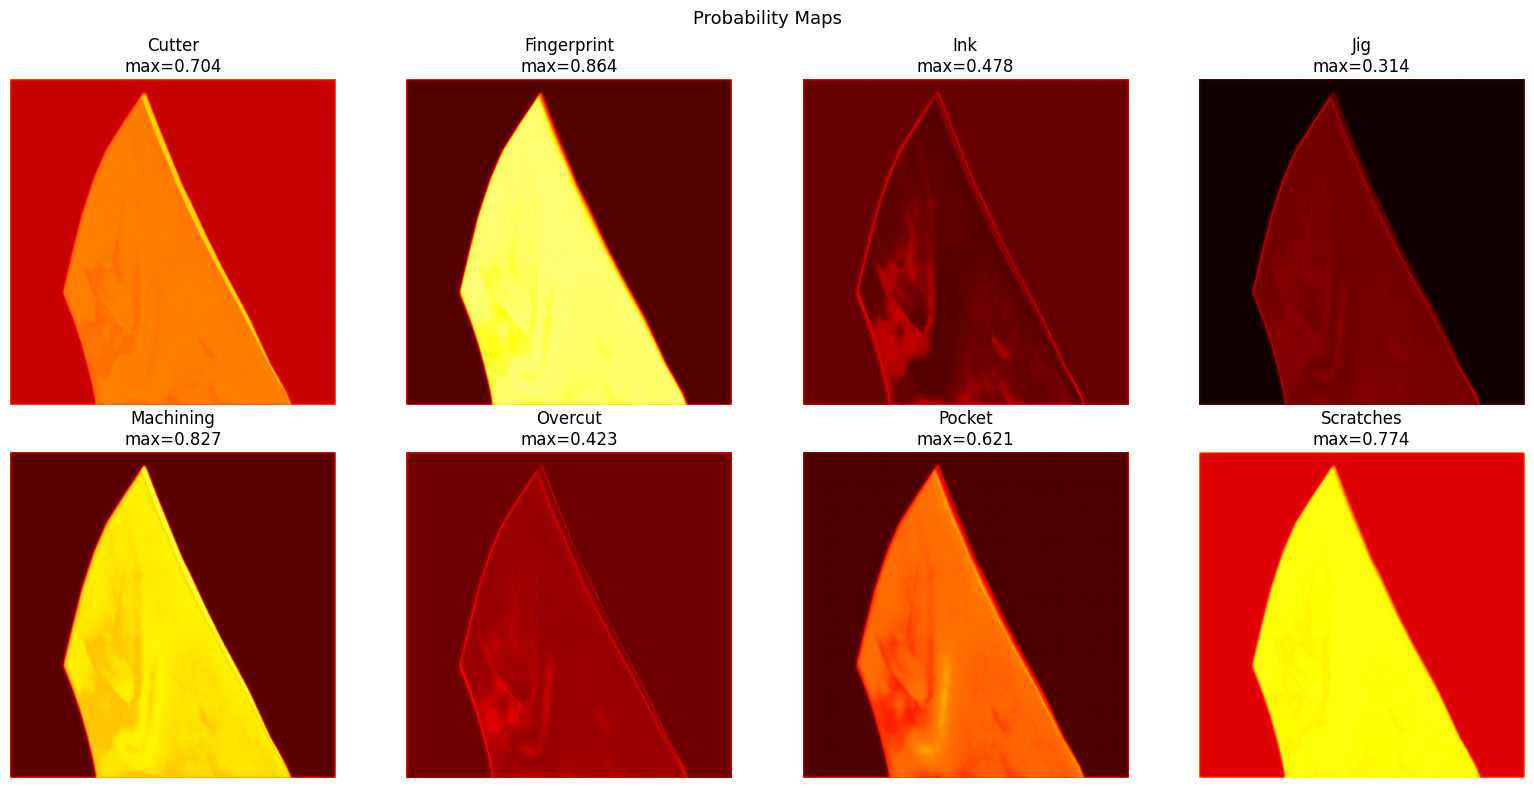

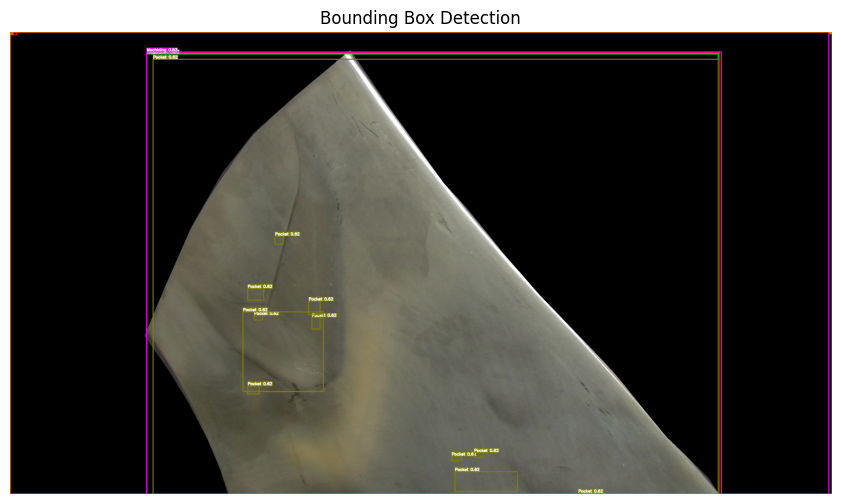

In [ ]:
img_rgb, pred, probs = predict("/content/dataset/images_masked/3664b495-75.jpg", threshold=0.5)
show_predictions(img_rgb, pred, probs)

#yolo seg model
not useful


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.7 MB/s eta 0:00:00


copy image to different path

In [ ]:
import shutil
import os
src_path = r"/content/drive/MyDrive/BFL/Annotations"
destination_path =r"/content/dataset"
if os.path.exists(src_path):
  shutil.copytree(src_path, destination_path)
  print("done copying")
else:
  print("file not found")

done copying


In [ ]:
content = """path: /content/dataset/

train: images/train
val: images/val

nc: 8

names:
  0: Cutter Marks and Fishmarks
  1: Fingerprint and Stains
  2: Ink Marks
  3: Jig Marks
  4: Machining Marks
  5: Overcut
  6: Pocket
  7: Scratches and Black spots"""

In [ ]:
with open("/content/dataset/data.yaml", "w") as f:
  f.write(content)

In [ ]:
import os
import shutil
import random

# Paths
# base_path = r"/content/drive/MyDrive/BFL/Defects/batch1/YOLO/project"
base_path = destination_path
images_path = os.path.join(base_path, "images")
labels_path = os.path.join(base_path, "labels")

# New folders
train_img = os.path.join(images_path, "train")
val_img = os.path.join(images_path, "val")
train_lbl = os.path.join(labels_path, "train")
val_lbl = os.path.join(labels_path, "val")

# Create folders
for path in [train_img, val_img, train_lbl, val_lbl]:
    os.makedirs(path, exist_ok=True)

# Get all images
images = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Shuffle images
random.shuffle(images)

# Split 80-20
split_index = int(0.8 * len(images))
train_files = images[:split_index]
val_files = images[split_index:]

def move_files(file_list, img_dest, lbl_dest):
    for img_file in file_list:
        name = os.path.splitext(img_file)[0]
        label_file = name + ".txt"

        # Source paths
        src_img = os.path.join(images_path, img_file)
        src_lbl = os.path.join(labels_path, label_file)

        # Destination paths
        dst_img = os.path.join(img_dest, img_file)
        dst_lbl = os.path.join(lbl_dest, label_file)

        # Move image
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)

        # Move label (only if exists)
        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dst_lbl)

# Move files
move_files(train_files, train_img, train_lbl)
move_files(val_files, val_img, val_lbl)

print("✅ Dataset split completed!")

✅ Dataset split completed!


In [ ]:
import os

base_path = destination_path

label_dirs = [
    os.path.join(base_path, "labels/train"),
    os.path.join(base_path, "labels/val")
]

image_dirs = [
    os.path.join(base_path, "images/train"),
    os.path.join(base_path, "images/val")
]

ignore_classes = [0]   # remove Blade
total_classes = 9

# Create mapping
new_class_id = {}
new_id = 0
for old_id in range(total_classes):
    if old_id not in ignore_classes:
        new_class_id[old_id] = new_id
        new_id += 1

print("Mapping:", new_class_id)

for labels_folder, images_folder in zip(label_dirs, image_dirs):

    for file in os.listdir(labels_folder):
        if not file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_folder, file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            try:
                cls = int(parts[0])
            except:
                continue

            if cls in ignore_classes:
                continue

            if cls not in new_class_id:
                continue

            parts[0] = str(new_class_id[cls])
            new_lines.append(" ".join(parts) + "\n")

        if len(new_lines) == 0:
            os.remove(label_path)
            img_name = file.replace(".txt", ".jpg")
            img_path = os.path.join(images_folder, img_name)

            if os.path.exists(img_path):
                os.remove(img_path)

        else:
            with open(label_path, "w") as f:
                f.writelines(new_lines)

Mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


In [ ]:
import os
import shutil
from collections import Counter

image_dir = "/content/dataset/images/train"
label_dir = "/content/dataset/labels/train"

minority_classes = [0, 3, 5]

dup_map = {
    0: 6,
    3: 6,
    5: 4
}

print("🔍 Counting class distribution BEFORE...")
class_counts = Counter()

# Count existing distribution
for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    with open(os.path.join(label_dir, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

print("Before:", dict(class_counts))


print("\n🚀 Starting duplication...")

for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    label_path = os.path.join(label_dir, file)

    # Read classes in file
    with open(label_path) as f:
        lines = f.readlines()

    classes_in_file = [int(line.split()[0]) for line in lines]

    # Check if any minority class exists
    target_classes = [c for c in classes_in_file if c in minority_classes]

    if not target_classes:
        continue

    # Decide duplication factor (max among classes in image)
    max_dup = max([dup_map.get(c, 1) for c in target_classes])

    # Image file
    img_file = file.replace(".txt", ".jpg")
    img_path = os.path.join(image_dir, img_file)

    if not os.path.exists(img_path):
        print(f"⚠️ Image not found for {file}, skipping...")
        continue

    # Duplicate
    for i in range(max_dup):
        new_label_name = file.replace(".txt", f"_dup{i}.txt")
        new_img_name = img_file.replace(".jpg", f"_dup{i}.jpg")

        new_label_path = os.path.join(label_dir, new_label_name)
        new_img_path = os.path.join(image_dir, new_img_name)

        shutil.copy(label_path, new_label_path)
        shutil.copy(img_path, new_img_path)

print("✅ Duplication done!")


print("\n🔍 Counting class distribution AFTER...")
class_counts_after = Counter()

for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    with open(os.path.join(label_dir, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts_after[cls] += 1

print("After:", dict(class_counts_after))

🔍 Counting class distribution BEFORE...
Before: {4: 148, 7: 708, 5: 54, 0: 53, 6: 14, 2: 179, 1: 283, 3: 41}

🚀 Starting duplication...
✅ Duplication done!

🔍 Counting class distribution AFTER...
After: {4: 712, 7: 2702, 5: 322, 3: 287, 0: 371, 1: 861, 6: 50, 2: 841}


In [ ]:
# import os
# import cv2
# import numpy as np

# # =========================
# # PATHS
# # =========================
# image_dir = "/content/dataset/images/train"
# label_dir = "/content/dataset/labels/train"

# out_img_dir = "/content/dataset_tiled/images/train"
# out_lbl_dir = "/content/dataset_tiled/labels/train"

# os.makedirs(out_img_dir, exist_ok=True)
# os.makedirs(out_lbl_dir, exist_ok=True)

# # =========================
# # TILING CONFIG
# # =========================
# TILE_SIZE = 640
# OVERLAP = 0.2   # 20% overlap

# STRIDE = int(TILE_SIZE * (1 - OVERLAP))


# # =========================
# # HELPER FUNCTIONS
# # =========================

# def read_labels(label_path):
#     """Read YOLO segmentation labels"""
#     objects = []
#     if not os.path.exists(label_path):
#         return objects

#     with open(label_path, "r") as f:
#         for line in f.readlines():
#             parts = list(map(float, line.strip().split()))
#             cls = int(parts[0])
#             polygon = np.array(parts[1:]).reshape(-1, 2)  # (x,y)
#             objects.append((cls, polygon))
#     return objects


# def convert_to_tile_coords(polygon, x_offset, y_offset, w, h):
#     """Convert normalized coords to tile coords"""
#     poly = polygon.copy()

#     # convert to pixel coords
#     poly[:, 0] = poly[:, 0] * w - x_offset
#     poly[:, 1] = poly[:, 1] * h - y_offset

#     return poly


# def normalize_polygon(poly, tile_size):
#     """Normalize polygon inside tile"""
#     poly[:, 0] = poly[:, 0] / tile_size
#     poly[:, 1] = poly[:, 1] / tile_size
#     return poly


# def clip_polygon(poly, tile_size):
#     """Clip polygon inside tile"""
#     poly[:, 0] = np.clip(poly[:, 0], 0, tile_size)
#     poly[:, 1] = np.clip(poly[:, 1], 0, tile_size)
#     return poly


# # =========================
# # MAIN TILING LOOP
# # =========================

# for img_file in os.listdir(image_dir):
#     if not img_file.endswith((".jpg", ".png")):
#         continue

#     img_path = os.path.join(image_dir, img_file)
#     label_path = os.path.join(label_dir, img_file.replace(".jpg", ".txt"))

#     image = cv2.imread(img_path)
#     h, w = image.shape[:2]

#     objects = read_labels(label_path)

#     tile_id = 0

#     for y in range(0, h, STRIDE):
#         for x in range(0, w, STRIDE):

#             tile = image[y:y+TILE_SIZE, x:x+TILE_SIZE]

#             if tile.shape[0] < TILE_SIZE or tile.shape[1] < TILE_SIZE:
#                 continue

#             new_labels = []

#             for cls, polygon in objects:
#                 poly = convert_to_tile_coords(polygon, x, y, w, h)

#                 # check if polygon is inside tile
#                 if np.any(
#                     (poly[:, 0] >= 0) & (poly[:, 0] <= TILE_SIZE) &
#                     (poly[:, 1] >= 0) & (poly[:, 1] <= TILE_SIZE)
#                 ):
#                     poly = clip_polygon(poly, TILE_SIZE)
#                     poly = normalize_polygon(poly, TILE_SIZE)

#                     flat = poly.reshape(-1)
#                     new_labels.append(f"{cls} " + " ".join(map(str, flat)))

#             # save only if labels exist
#             if len(new_labels) > 0:
#                 tile_name = img_file.replace(".jpg", f"_tile{tile_id}.jpg")

#                 cv2.imwrite(os.path.join(out_img_dir, tile_name), tile)

#                 with open(os.path.join(out_lbl_dir, tile_name.replace(".jpg", ".txt")), "w") as f:
#                     f.write("\n".join(new_labels))

#                 tile_id += 1

# print("✅ Tiling completed!")

In [ ]:
from ultralytics import YOLO

# Load segmentation model
model = YOLO("yolov8l-seg.pt")
model.train(
    data="dataset/data.yaml",
    epochs=100,
    imgsz=1024,
    batch=4,
    hsv_h=0.1,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    fliplr=0.5,
    augment=True
    # cls_weights=[0.0,1.0,1.0,1.0,1.0, 1.0, 1.0,1.0]
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.1, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=

In [ ]:
from ultralytics import YOLO

# Load trained model
model = YOLO("runs/segment/train/weights/best.pt")

# Test on image
results = model.predict(
    source="/content/dataset/images/val",
    save=True,
    show=True,   # display output
    conf=0.5
)

print("✅ Testing done!")

In [ ]:
import matplotlib.pyplot as plt
import PIL.Image
import os

# Directory where predicted images are saved by YOLOv8 (default for predict)
# This is typically 'runs/segment/predict' within the current working directory ('/content/')
predicted_images_base_dir = "/content/runs/segment/predict"

# Check if the predicted_images_base_dir exists
if not os.path.exists(predicted_images_base_dir):
    print(f"Predicted images directory not found: {predicted_images_base_dir}")
    print("Please ensure `model.predict(save=True)` was run successfully and check the output directory.")
else:
    print(f"Found predicted images directory: {predicted_images_base_dir}")

    # Iterate through the prediction results
    for i, result in enumerate(results):
        # result.path gives the full path to the original image
        original_image_path = result.path

        # Get the filename from the original path
        image_filename = os.path.basename(original_image_path)

        # Construct the path to the predicted image
        # YOLOv8 saves predicted images with the same filename in its output directory
        predicted_image_path = os.path.join(predicted_images_base_dir, image_filename)

        if not os.path.exists(predicted_image_path):
            print(f"Predicted image not found for {image_filename} at {predicted_image_path}. Skipping.")
            continue

        try:
            # Load original image
            original_image = PIL.Image.open(original_image_path)
            # Load predicted image (with bounding boxes and masks drawn on it)
            predicted_image = PIL.Image.open(predicted_image_path)

            # Display side by side
            fig, axes = plt.subplots(1, 2, figsize=(15, 7))
            axes[0].imshow(original_image)
            axes[0].set_title(f"Original: {image_filename}")
            axes[0].axis('off')

            axes[1].imshow(predicted_image)
            axes[1].set_title(f"Predicted: {image_filename}")
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()

            if i >= 20: # Show first 5 results to avoid too many plots
                print("Showing first 5 pairs. Modify the code to view more.")
                break

        except Exception as e:
            print(f"Error processing image {image_filename}: {e}")

In [ ]:
# import torch
# torch.cuda.empty_cache()
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
!git clone https://github.com/leekunhee/Mask_RCNN.git
%cd Mask_RCNN

!pip install -r requirements.txt

In [ ]:
from mrcnn import model as modellib

In [ ]:
model.load_weights("old_model.h5", by_name=True)

In [ ]:
CLASS_NAMES = [
    "BG",
    "scratches",
    "no sharp edge",
    "fingerprint and stains",
    "machining mark",
    "dent marks"
]

In [ ]:
from mrcnn.config import Config

class InferenceConfig(Config):
    NAME = "defect_old"

    GPU_COUNT = 1
    IMAGES_PER_GPU = 1

    NUM_CLASSES = len(CLASS_NAMES)

    DETECTION_MIN_CONFIDENCE = 0.3

In [ ]:
from mrcnn import model as modellib

model = modellib.MaskRCNN(
    mode="inference",
    config=InferenceConfig(),
    model_dir="/content/logs"
)

model.load_weights(
    "/content/drive/MyDrive/BFL/Old_dataset_sdk/data_1/Model/mask_rcnn_bfl_0020_res4.h5",
    by_name=True
)

In [ ]:
import cv2

image_path = "/content/131.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = model.detect([image], verbose=1)
r = results[0]

#RTM
useless

In [28]:
# Clean install (no conflicts)
!pip install -U openmim

# Install core libs
!mim install "mmengine>=0.7.0"
!mim install "mmcv>=2.0.0"
!mim install "mmdet>=3.0.0"

Traceback (most recent call last):
  File "/usr/local/bin/mim", line 5, in <module>
    from mim.cli import cli
  File "/usr/local/lib/python3.12/dist-packages/mim/__init__.py", line 10, in <module>
    import setuptools  # noqa: F401
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/setuptools/__init__.py", line 16, in <module>
    import setuptools.version
  File "/usr/local/lib/python3.12/dist-packages/setuptools/version.py", line 1, in <module>
    import pkg_resources
  File "/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py", line 2172, in <module>
    register_finder(pkgutil.ImpImporter, find_on_path)
                    ^^^^^^^^^^^^^^^^^^^
AttributeError: module 'pkgutil' has no attribute 'ImpImporter'. Did you mean: 'zipimporter'?
Traceback (most recent call last):
  File "/usr/local/bin/mim", line 5, in <module>
    from mim.cli import cli
  File "/usr/local/lib/python3.12/dist-packages/mim/__init__.py", line 10, in <module>
    import setu

In [2]:
import shutil
import os
src_path = r"/content/drive/MyDrive/BFL/Annotations/RTM"
destination_path =r"/content/dataset_RTM"
if os.path.exists(src_path):
  shutil.copytree(src_path, destination_path)
  print("done copying")
else:
  print("file not found")

done copying


In [8]:
import json

# 🔥 INPUT / OUTPUT
INPUT_JSON = "dataset_RTM/result.json"
OUTPUT_JSON = "dataset_RTM/results.json"

# 🔥 Classes you want
TARGET_CLASSES = [
    "Scratches and Black spots",
    "Fingerprint and Stains",
    "Machining Marks"
]

with open(INPUT_JSON) as f:
    coco = json.load(f)

# -------------------------------
# 1. FILTER CATEGORIES
# -------------------------------
filtered_categories = [
    cat for cat in coco["categories"]
    if cat["name"] in TARGET_CLASSES
]

# -------------------------------
# 2. CREATE NEW ID MAP (1,2,3)
# -------------------------------
old_to_new = {}

for new_id, cat in enumerate(filtered_categories, start=1):
    old_to_new[cat["id"]] = new_id
    cat["id"] = new_id  # update category id

# -------------------------------
# 3. FILTER ANNOTATIONS
# -------------------------------
filtered_annotations = [
    ann for ann in coco["annotations"]
    if ann["category_id"] in old_to_new
]

# -------------------------------
# 4. REMAP ANNOTATION IDS
# -------------------------------
for ann in filtered_annotations:
    ann["category_id"] = old_to_new[ann["category_id"]]

# -------------------------------
# 5. KEEP ONLY USED IMAGES
# -------------------------------
valid_image_ids = set(ann["image_id"] for ann in filtered_annotations)

filtered_images = [
    img for img in coco["images"]
    if img["id"] in valid_image_ids
]

# -------------------------------
# 6. SAVE FINAL JSON
# -------------------------------
filtered_coco = {
    "images": filtered_images,
    "annotations": filtered_annotations,
    "categories": filtered_categories
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(filtered_coco, f)

print("✅ Done")
print("New Categories:", filtered_categories)

✅ Done
New Categories: [{'id': 1, 'name': 'Fingerprint and Stains'}, {'id': 2, 'name': 'Machining Marks'}, {'id': 3, 'name': 'Scratches and Black spots'}]


In [22]:
import json
import os

INPUT_JSON = "/content/dataset_RTM/results.json"
OUTPUT_JSON = "/content/dataset_RTM/results.json"

with open(INPUT_JSON) as f:
    coco = json.load(f)

# 🔥 FORCE FIX (handles Windows paths correctly)
for img in coco["images"]:
    path = img["file_name"]
    filename = path.split("\\")[-1]   # split Windows path
    img["file_name"] = filename

with open(OUTPUT_JSON, "w") as f:
    json.dump(coco, f)

print("✅ FORCE FIX DONE")

✅ FORCE FIX DONE


In [23]:
with open("/content/dataset_RTM/results_fixed.json") as f:
    coco = json.load(f)

for i in range(5):
    print(coco["images"][i]["file_name"])

27f2a692-Copy_of_15792344_aerofoil_trailing_edge_base.jpg
a5def041-Copy_of_221110298_aerofoil_trailing_edge_opp_pocket_base.jpg
3fd5acdd-Copy_of_221110298Aerofoil_trailing_edge_opp_pocket_base.jpg
881aef74-Copy_of_238107259_aerofoil_middle_base_opp_pocket.jpg
6d953d99-Copy_of_238107259_Aerofoil_middle_opp_pocket_base.jpg


In [24]:
import json
import os
import random
import shutil

# 🔥 PATHS (CHANGE)
IMG_DIR = r"dataset_RTM/images"
ANN_FILE = "dataset_RTM/results.json"

OUT_DIR = "dataset"

os.makedirs(f"{OUT_DIR}/images/train", exist_ok=True)
os.makedirs(f"{OUT_DIR}/images/val", exist_ok=True)
os.makedirs(f"{OUT_DIR}/annotations", exist_ok=True)

# load json
with open(ANN_FILE) as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

# shuffle
random.shuffle(images)

split = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

def filter_annotations(imgs):
    ids = set(i["id"] for i in imgs)
    return [a for a in annotations if a["image_id"] in ids]

train_anns = filter_annotations(train_imgs)
val_anns = filter_annotations(val_imgs)

def save_json(imgs, anns, path):
    with open(path, "w") as f:
        json.dump({
            "images": imgs,
            "annotations": anns,
            "categories": coco["categories"]
        }, f)

save_json(train_imgs, train_anns, f"{OUT_DIR}/annotations/train.json")
save_json(val_imgs, val_anns, f"{OUT_DIR}/annotations/val.json")

def copy_images(imgs, dst):
    for img in imgs:
        src = os.path.join(IMG_DIR, img["file_name"])
        dst_path = os.path.join(dst, img["file_name"])
        shutil.copy(src, dst_path)

copy_images(train_imgs, f"{OUT_DIR}/images/train")
copy_images(val_imgs, f"{OUT_DIR}/images/val")

print("✅ Dataset ready")

✅ Dataset ready


In [25]:
classes = (
    'Scratches and Black spots',
    'Fingerprint and Stains',
    'Machining Marks'
)

In [26]:
data_root = "/content/dataset/"   # 🔥 CHANGE PATH

config = f"""
_base_ = 'mmdet::rtmdet/rtmdet-ins_s_8xb32-300e_coco.py'

data_root = '{data_root}'

metainfo = {{
    'classes': {classes}
}}

# ================= DATA =================
train_dataloader = dict(
    batch_size=4,
    num_workers=2,
    dataset=dict(
        type='CocoDataset',
        data_root=data_root,
        ann_file='annotations/train.json',
        data_prefix=dict(img='images/train/'),
        metainfo=metainfo
    )
)

val_dataloader = dict(
    batch_size=2,
    num_workers=2,
    dataset=dict(
        type='CocoDataset',
        data_root=data_root,
        ann_file='annotations/val.json',
        data_prefix=dict(img='images/val/'),
        metainfo=metainfo
    )
)

# ================= MODEL =================
model = dict(
    bbox_head=dict(num_classes=3),
    mask_head=dict(num_classes=3)
)

# ================= PRETRAIN =================
load_from = 'https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet-ins_s_8xb32-300e_coco/rtmdet-ins_s_8xb32-300e_coco_20221124_090715-9f0c6c2a.pth'

# ================= TRAIN =================
train_cfg = dict(max_epochs=50)

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=0.0001)
)

# ================= PIPELINE (IMPORTANT FOR SMALL DEFECTS) =================
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),

    # 🔥 critical for tiny defects
    dict(type='Resize', scale=(1024, 1024), keep_ratio=True),

    dict(type='RandomFlip', prob=0.5),

    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(1024, 1024), keep_ratio=True),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='PackDetInputs')
]
"""

with open("rtmdet_final.py", "w") as f:
    f.write(config)

In [27]:
!python -m mmdet.tools.train rtmdet_final.py

/usr/bin/python3: Error while finding module specification for 'mmdet.tools.train' (ModuleNotFoundError: No module named 'mmdet')


In [ ]:
# import torch
# import torchvision
# from torchvision.models.detection import maskrcnn_resnet50_fpn
# from torchvision.datasets import CocoDetection
# from torch.utils.data import DataLoader
# import torchvision.transforms as T

# class CocoSegDataset(CocoDetection):
#     def __getitem__(self, idx):
#         img, target = super().__getitem__(idx)

#         boxes = []
#         masks = []
#         labels = []

#         for obj in target:
#             boxes.append(obj["bbox"])
#             labels.append(obj["category_id"])
#             masks.append(obj["segmentation"])

#         boxes = torch.tensor(boxes, dtype=torch.float32)
#         labels = torch.tensor(labels, dtype=torch.int64)

#         target = {
#             "boxes": boxes,
#             "labels": labels
#         }

#         return T.ToTensor()(img), target

# train_dataset = CocoSegDataset(
#     root="dataset/images/train",
#     annFile="dataset/annotations/train.json"
# )

# val_dataset = CocoSegDataset(
#     root="dataset/images/val",
#     annFile="dataset/annotations/val.json"
# )

# train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

# model = maskrcnn_resnet50_fpn(pretrained=True)
# model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
#     model.roi_heads.box_predictor.cls_score.in_features, 8)

# model.to("cuda")

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# for epoch in range(10):
#     model.train()
#     for imgs, targets in train_loader:
#         imgs = [img.cuda() for img in imgs]

#         loss_dict = model(imgs, targets)
#         loss = sum(loss_dict.values())

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#     print(f"Epoch {epoch} Loss:", loss.item())

#yolact
useless

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import json
import os
import random
import shutil

# paths
images_dir = "/content/drive/MyDrive/BFL/Old_dataset_sdk/data_1/Annotations/Base/Seperate JSON/Batch_1/"
annotation_file = "/content/drive/MyDrive/BFL/Old_dataset_sdk/data_1/Annotations/Base/Seperate JSON/Batch_1/batch_1_coco_imglab.json"

train_dir = "dataset/images/train"
val_dir = "dataset/images/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs("dataset/annotations", exist_ok=True)

# load json
with open(annotation_file) as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

# shuffle images
random.shuffle(images)

split_ratio = 0.8
split_index = int(len(images) * split_ratio)

train_images = images[:split_index]
val_images = images[split_index:]

train_ids = {img["id"] for img in train_images}
val_ids = {img["id"] for img in val_images}

train_annotations = [ann for ann in annotations if ann["image_id"] in train_ids]
val_annotations = [ann for ann in annotations if ann["image_id"] in val_ids]

# copy images
for img in train_images:
    shutil.copy(os.path.join(images_dir, img["file_name"]), train_dir)

for img in val_images:
    shutil.copy(os.path.join(images_dir, img["file_name"]), val_dir)

# create json files
train_json = {
    "images": train_images,
    "annotations": train_annotations,
    "categories": coco["categories"]
}

val_json = {
    "images": val_images,
    "annotations": val_annotations,
    "categories": coco["categories"]
}

with open("dataset/annotations/instances_train.json", "w") as f:
    json.dump(train_json, f)

with open("dataset/annotations/instances_val.json", "w") as f:
    json.dump(val_json, f)

print("Dataset split complete")

Dataset split complete


In [ ]:
!git clone https://github.com/dbolya/yolact.git
!cd yolact

Cloning into 'yolact'...
remote: Enumerating objects: 2942, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 2942 (delta 2), reused 1 (delta 1), pack-reused 2938 (from 2)
Receiving objects: 100% (2942/2942), 21.21 MiB | 21.83 MiB/s, done.
Resolving deltas: 100% (2004/2004), done.


In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
!pip install torch torchvision cython opencv-python matplotlib
!pip install pycocotools

In [ ]:
import re
import os

config_file_path = "/content/yolact/data/config.py"

with open(config_file_path, "r") as f:
    config_content = f.read()

# Pattern to find the coco2017_dataset definition
pattern = r"(coco2017_dataset\s*=\s*dataset_base\.copy\(\{\s*\'name\':\s*'COCO 2017',\s*\'train_images\':\s*'.*?',\s*\'train_info\':\s*'.*?',\s*\'valid_images\':\s*'.*?',\s*\'valid_info\':\s*'.*?'(?:,\s*\'label_map\':\s*.*?)?\s*\}\))"

def replace_coco_config(match):
    block = match.group(0)

    # Update paths
    block = re.sub(r"\'train_images\':\s*'.*?'", "'train_images': '/content/dataset/images/train'", block)
    block = re.sub(r"\'train_info\':\s*'.*?'",   "'train_info':   '/content/dataset/annotations/instances_train.json'", block)
    block = re.sub(r"\'valid_images\':\s*'.*?'", "'valid_images': '/content/dataset/images/val'", block)
    block = re.sub(r"\'valid_info\':\s*'.*?'",   "'valid_info':   '/content/dataset/annotations/instances_val.json'", block)

    # Add or update 'label_map': None
    if "'label_map':" in block:
        block = re.sub(r"\'label_map\':\s*.*", "'label_map': None", block)
    else:
        block_lines = block.split('\n')
        for i in range(len(block_lines) - 1, -1, -1):
            if '})' in block_lines[i]:
                block_lines.insert(i, "    'label_map': None,")
                break
        block = '\n'.join(block_lines)

    return block

new_config_content = re.sub(pattern, replace_coco_config, config_content, flags=re.DOTALL)

with open(config_file_path, "w") as f:
    f.write(new_config_content)

print("config.py updated successfully with custom dataset paths and label_map=None.")

# Modify train.py to print debug information
train_py_path = "/content/yolact/train.py"
with open(train_py_path, "r") as f:
    train_py_content = f.read()

# Find the line where COCODetection is called and insert print statements before it
# This regex looks for the COCODetection constructor and captures the preceding lines
# to insert the debug prints just before it.
search_pattern = r"(dataset\s*=\s*COCODetection\(image_path=cfg\.dataset\.train_images,\s*info_file=cfg\.dataset\.train_info,\s*transform=TrainTransform\(\)\))"

# Check if the print statements are already there to avoid duplicates
if "DEBUG: cfg.dataset.train_images" not in train_py_content:
    replacement = (
        "    print(f\"DEBUG: cfg.dataset.train_images: {cfg.dataset.train_images}\")\n" +
        "    print(f\"DEBUG: cfg.dataset.train_info: {cfg.dataset.train_info}\")\n" +
        r"\1"
    )
    train_py_content = re.sub(search_pattern, replacement, train_py_content, flags=re.DOTALL)

    with open(train_py_path, "w") as f:
        f.write(train_py_content)
    print("Added debug prints to train.py")
else:
    print("Debug prints already exist in train.py")

!python /content/yolact/train.py

config.py updated successfully with custom dataset paths and label_map=None.
Added debug prints to train.py
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1305: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)
loading annotations into memory...
Traceback (most recent call last):
  File "/content/yolact/train.py", line 504, in <module>
    train()
  File "/content/yolact/train.py", line 176, in train
    dataset = COCODetection(image_path=cfg.dataset.train_images,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolact/data/coco.py", line 74, in __init__
    self.coco = COCO(info_file)
                ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pycocotools/coco.py", line 81, in __init__
    with open(anno

# For Testing with sahi tiling model using best.pt

In [ ]:
pip install -U ultralytics sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [ ]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2

# ----------------------------
# Load your trained model
# ----------------------------

model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="/content/best (4).pt",   # your trained model)
    confidence_threshold=0.25,
    device="cuda"  # use "cpu" if no GPU
)

# ----------------------------
# Run SAHI sliced inference
# ----------------------------
result = get_sliced_prediction(
    "/content/131.jpg",   # input image path
    model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

# ----------------------------
# Export results
# ----------------------------
result.export_visuals(export_dir="content/outputs/")

# Optional: get predictions programmatically
preds = result.object_prediction_list

print(f"Total detections: {len(preds)}")

Performing prediction on 60 slices.
Total detections: 20


In [ ]:
for obj in result.object_prediction_list:
    print("Class:", obj.category.name)
    print("Score:", obj.score.value)

    # segmentation mask
    mask = obj.mask.bool_mask  # numpy array

Class: Machining Marks
Score: 0.9559083580970764
Class: Machining Marks
Score: 0.9078433513641357
Class: Machining Marks
Score: 0.8942901492118835
Class: Machining Marks
Score: 0.887054443359375
Class: Machining Marks
Score: 0.6737663149833679
Class: Machining Marks
Score: 0.6424154043197632
Class: Machining Marks
Score: 0.6178383827209473
Class: Machining Marks
Score: 0.6115418076515198
Class: Machining Marks
Score: 0.6075595021247864
Class: Machining Marks
Score: 0.5774162411689758
Class: Machining Marks
Score: 0.5541064143180847
Class: Machining Marks
Score: 0.5061399340629578
Class: Machining Marks
Score: 0.36843618750572205
Class: Machining Marks
Score: 0.31747666001319885
Class: Machining Marks
Score: 0.2936791777610779
Class: Machining Marks
Score: 0.25518086552619934
Class: Scratches and Black spots
Score: 0.6198055148124695
Class: Scratches and Black spots
Score: 0.2932593822479248
Class: Scratches and Black spots
Score: 0.264534592628479
Class: Scratches and Black spots
Score

Displaying images from: content/outputs/


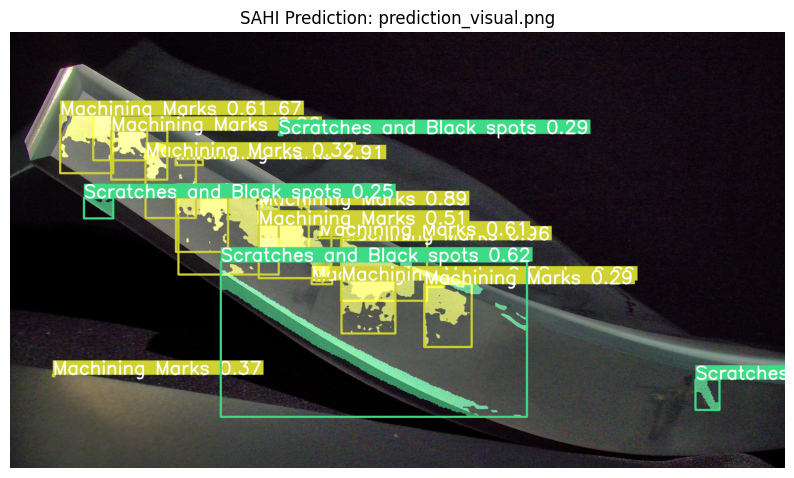

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2

output_dir = "content/outputs/"

if not os.path.exists(output_dir):
    print(f"Output directory '{output_dir}' not found. Please ensure SAHI predictions were exported.")
else:
    print(f"Displaying images from: {output_dir}")
    image_files = [f for f in os.listdir(output_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    image_files.sort() # Display in a consistent order

    for i, img_name in enumerate(image_files):
        if i >= 5: # Limit to first 5 images for brevity
            print("Showing first 5 SAHI prediction images. Modify code to view more.")
            break

        img_path = os.path.join(output_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(image)
        plt.title(f"SAHI Prediction: {img_name}")
        plt.axis('off')
        plt.show()

#TIling Training

In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path

# =========================
# PATHS
# =========================
image_dir = "dataset/images/train"
label_dir = "dataset/labels/train"

out_img_dir = "dataset_hybrid/images/train"
out_lbl_dir = "dataset_hybrid/labels/train"

os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

# =========================
# SETTINGS
# =========================
TILE_SIZE = 512
OVERLAP = 0.2
STRIDE = int(TILE_SIZE * (1 - OVERLAP))

# =========================
# HELPER FUNCTIONS
# =========================
def load_yolo_seg_labels(label_path):
    labels = []
    if not os.path.exists(label_path):
        return labels

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = list(map(float, line.strip().split()))
            cls = int(parts[0])
            poly = np.array(parts[1:]).reshape(-1, 2)
            labels.append((cls, poly))
    return labels


def save_yolo_seg_labels(label_path, labels):
    with open(label_path, "w") as f:
        for cls, poly in labels:
            poly_flat = poly.reshape(-1)
            line = str(cls) + " " + " ".join(map(str, poly_flat))
            f.write(line + "\n")


def clip_polygon(poly, x1, y1, x2, y2, img_w, img_h):
    # convert normalized → absolute
    poly_abs = poly.copy()
    poly_abs[:, 0] *= img_w
    poly_abs[:, 1] *= img_h

    # shift to tile
    poly_abs[:, 0] -= x1
    poly_abs[:, 1] -= y1

    # keep points inside tile
    mask = (
        (poly_abs[:, 0] >= 0) & (poly_abs[:, 0] <= (x2 - x1)) &
        (poly_abs[:, 1] >= 0) & (poly_abs[:, 1] <= (y2 - y1))
    )
    poly_abs = poly_abs[mask]

    if len(poly_abs) < 3:
        return None

    # normalize again
    poly_abs[:, 0] /= (x2 - x1)
    poly_abs[:, 1] /= (y2 - y1)

    return poly_abs


# =========================
# MAIN LOOP
# =========================
for img_name in os.listdir(image_dir):
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    image = cv2.imread(img_path)
    if image is None:
        continue

    h, w = image.shape[:2]
    labels = load_yolo_seg_labels(label_path)

    # ---- SAVE ORIGINAL (HYBRID PART) ----
    cv2.imwrite(os.path.join(out_img_dir, img_name), image)
    if os.path.exists(label_path):
        os.system(f"cp {label_path} {os.path.join(out_lbl_dir, img_name.replace('.jpg','.txt'))}")

    # ---- TILING ----
    tile_id = 0

    for y in range(0, h, STRIDE):
        for x in range(0, w, STRIDE):

            x2 = min(x + TILE_SIZE, w)
            y2 = min(y + TILE_SIZE, h)

            tile = image[y:y2, x:x2]

            if tile.shape[0] < TILE_SIZE//2 or tile.shape[1] < TILE_SIZE//2:
                continue

            new_labels = []

            for cls, poly in labels:
                clipped = clip_polygon(poly, x, y, x2, y2, w, h)
                if clipped is not None:
                    new_labels.append((cls, clipped))

            if len(new_labels) == 0:
                continue

            tile_name = f"{Path(img_name).stem}_{tile_id}.jpg"

            cv2.imwrite(os.path.join(out_img_dir, tile_name), tile)
            save_yolo_seg_labels(
                os.path.join(out_lbl_dir, tile_name.replace(".jpg", ".txt")),
                new_labels
            )

            tile_id += 1

print("✅ Hybrid tiling dataset created!")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8l-seg.pt")

model.train(
    data="dataset_hybrid/data.yaml",
    epochs=100,
    imgsz=512
)

#SAM

In [ ]:
!git clone https://github.com/facebookresearch/segment-anything-2
%cd /content/segment-anything-2
!pip install -q -e .

Cloning into 'segment-anything-2'...
remote: Enumerating objects: 1096, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
fetch-pack: unexpected disconnect while reading sideband packet
^C
[Errno 2] No such file or directory: '/content/segment-anything-2'
/content/Mask_RCNN
  Preparing metadata (setup.py) ... done


In [ ]:
!wget -O sam2_hiera_tiny.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt"
!wget -O sam2_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt"
!wget -O sam2_hiera_base_plus.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt"
!wget -O sam2_hiera_large.pt "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt"

--2026-03-16 19:35:15--  https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.39, 13.249.182.81, 13.249.182.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 155906050 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2_hiera_tiny.pt’

sam2_hiera_tiny.pt  100%[===================>] 148.68M   316MB/s    in 0.5s    

2026-03-16 19:35:16 (316 MB/s) - ‘sam2_hiera_tiny.pt’ saved [155906050/155906050]

--2026-03-16 19:35:16--  https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.39, 13.249.182.81, 13.249.182.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184309650 (176M) [applicat

In [ ]:
from google.colab import files
files.upload()


#maskrcnn

In [ ]:
!pip install pyyaml==5.1
!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu118/torch2.0/index.html

In [ ]:
import os, json, cv2
import numpy as np
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import BoxMode

In [ ]:
IMG_DIR = "/content/dataset/images"
LABEL_DIR = "/content/dataset/labels"

CLASS_MAP = {
    0: 0,  # surface
    1: 1,  # contamination
    2: 1,
    3: 0,
    4: 0,
    5: 2,  # structural
    6: 2,
    7: 2
}

CLASS_NAMES = ["surface", "contamination", "structural"]

def get_dataset():
    dataset_dicts = []

    for idx, img_name in enumerate(os.listdir(IMG_DIR)):
        record = {}

        img_path = os.path.join(IMG_DIR, img_name)
        label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        record["file_name"] = img_path
        record["image_id"] = idx
        record["height"] = h
        record["width"] = w

        objs = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                parts = list(map(float, line.strip().split()))
                cls_raw = int(parts[0])

                if cls_raw not in CLASS_MAP:
                    continue

                cls = CLASS_MAP[cls_raw]
                coords = parts[1:]

                poly = []
                for i in range(0, len(coords), 2):
                    x = coords[i] * w
                    y = coords[i+1] * h
                    poly.extend([x, y])

                xs = poly[0::2]
                ys = poly[1::2]

                bbox = [min(xs), min(ys), max(xs), max(ys)]

                obj = {
                    "bbox": bbox,
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "segmentation": [poly],
                    "category_id": cls
                }

                objs.append(obj)

        record["annotations"] = objs
        dataset_dicts.append(record)

    return dataset_dicts

In [ ]:
DatasetCatalog.register("blade_train", get_dataset)
MetadataCatalog.get("blade_train").set(thing_classes=CLASS_NAMES)

metadata = MetadataCatalog.get("blade_train")

In [ ]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()

cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.DATASETS.TRAIN = ("blade_train",)
cfg.DATASETS.TEST = ()

cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 2000   # small dataset

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3

cfg.OUTPUT_DIR = "/content/output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

In [ ]:
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer

cfg.MODEL.WEIGHTS = "/content/output/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3

predictor = DefaultPredictor(cfg)

In [ ]:
img = cv2.imread("/content/test.jpg")

outputs = predictor(img)

v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=1.0)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

import matplotlib.pyplot as plt
plt.imshow(out.get_image())
plt.axis("off")
plt.show()

#RTM

In [ ]:
pip install openmim
mim install mmengine
mim install "mmcv>=2.0.0"
mim install mmdet